In [47]:
#Import dependencies
import os
import pandas as pd
import numpy as np
import numpy_financial as npf
import seaborn as sns
from scripts.gep_functions import *
pd.options.mode.chained_assignment = None
import matplotlib.pyplot as plt
%matplotlib inline

## Data exploration

Descriptive statistics

In [2]:
path=os.getcwd()+ '/results'

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        print(scenario)
        
        
        print(df[["Ft_PerTonRes","MinimumOverallLCOE2030","TotalEnergyPerCell","Pop2030"]].describe())
        

ng-2-0_0_0_0_1_0-results
       Ft_PerTonRes  MinimumOverallLCOE2030  TotalEnergyPerCell       Pop2030
count   2388.000000             2388.000000         2388.000000   2388.000000
mean     -35.152507                0.447072        28425.773043    994.751811
std      102.877809                0.180364        24162.963294   1457.521672
min     -537.767129                0.170000         4091.272000     10.530000
25%      -83.702900                0.268800        16585.172000    130.575000
50%      -52.992103                0.513200        21939.583000    599.000000
75%       -5.247597                0.611000        31746.300000   1283.000000
max      889.625449                1.350000       483701.880000  29420.000000
ng-2-0_0_0_1_1_0-results
       Ft_PerTonRes  MinimumOverallLCOE2030  TotalEnergyPerCell       Pop2030
count     51.000000               51.000000        5.100000e+01     51.000000
mean     -27.368972                0.177563        4.166403e+05   1841.435098
std      109.1

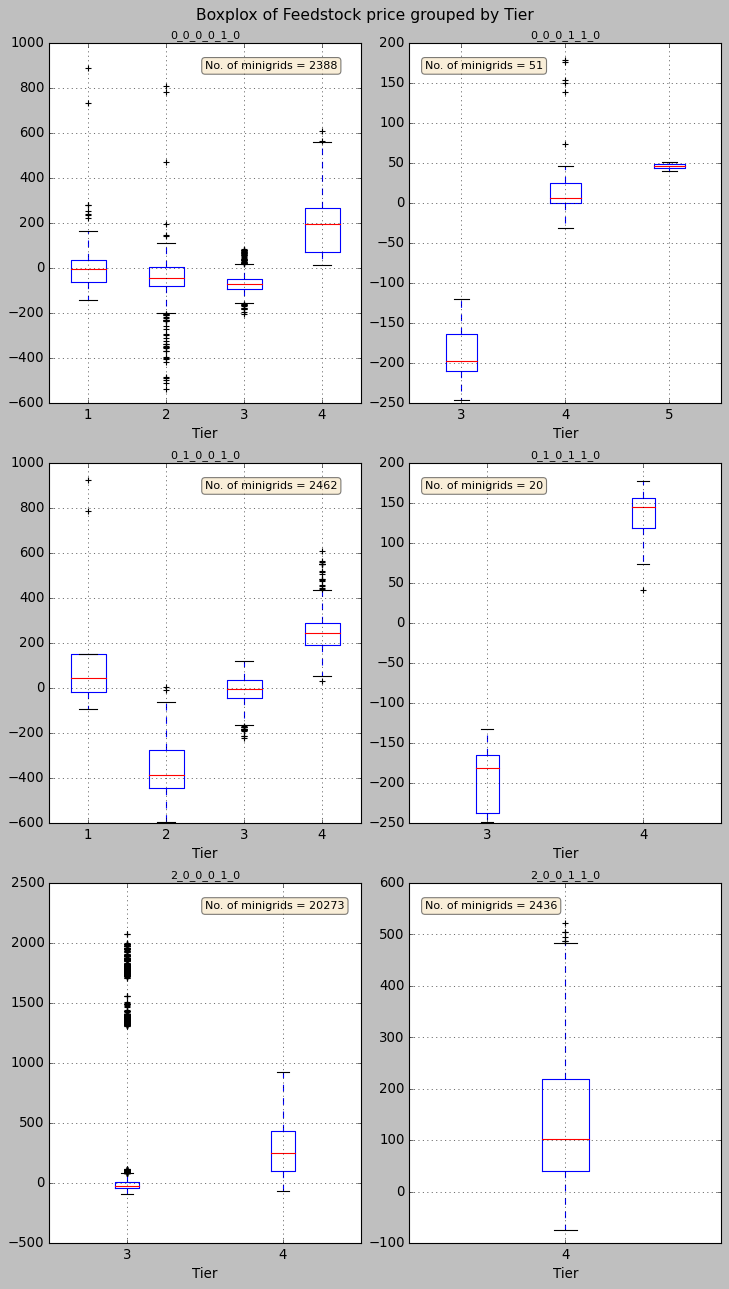

In [3]:
counter = 0
# Initialise the subplot function using number of rows and columns
plt.style.use('classic') 
figure, axis = plt.subplots(3, 2, figsize=(9,16), layout='constrained')

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        textstr = f'No. of minigrids = {len(df)}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        
        if counter == 0:
            df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[counter,0].set_title(scenario.split('-')[2], fontsize=10)
            axis[counter,0].text(0.5, 0.95, textstr, transform=axis[counter,0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
        
        elif counter%2 == 0:
            df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter//2,0])
            axis[counter//2,0].set_title(scenario.split('-')[2], fontsize=10)    
            axis[counter//2,0].text(0.5, 0.95, textstr, transform=axis[counter//2,0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
        elif counter == 3:
            df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[1, 1])
            axis[1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[1,1].text(0.05, 0.95, textstr, transform=axis[1,1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
        elif counter == 5:
            df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[2, 1])
            axis[2, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[2,1].text(0.05, 0.95, textstr, transform=axis[2,1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
        else:
            df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[(counter%2)-1, 1])
            axis[(counter%2)-1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[(counter%2)-1, 1].text(0.05, 0.95, textstr, transform=axis[(counter%2)-1, 1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
          
        counter+=1
    
figure.suptitle('Boxplox of Feedstock price grouped by Tier', fontsize=14)
plt.show()

## Comment

surprisingly bsesides Tier 4, Tier 5 some Tier 3, Tier 1 also fairs well.

## Display CDF of selecected scenarios

In [4]:
plt.close('all')

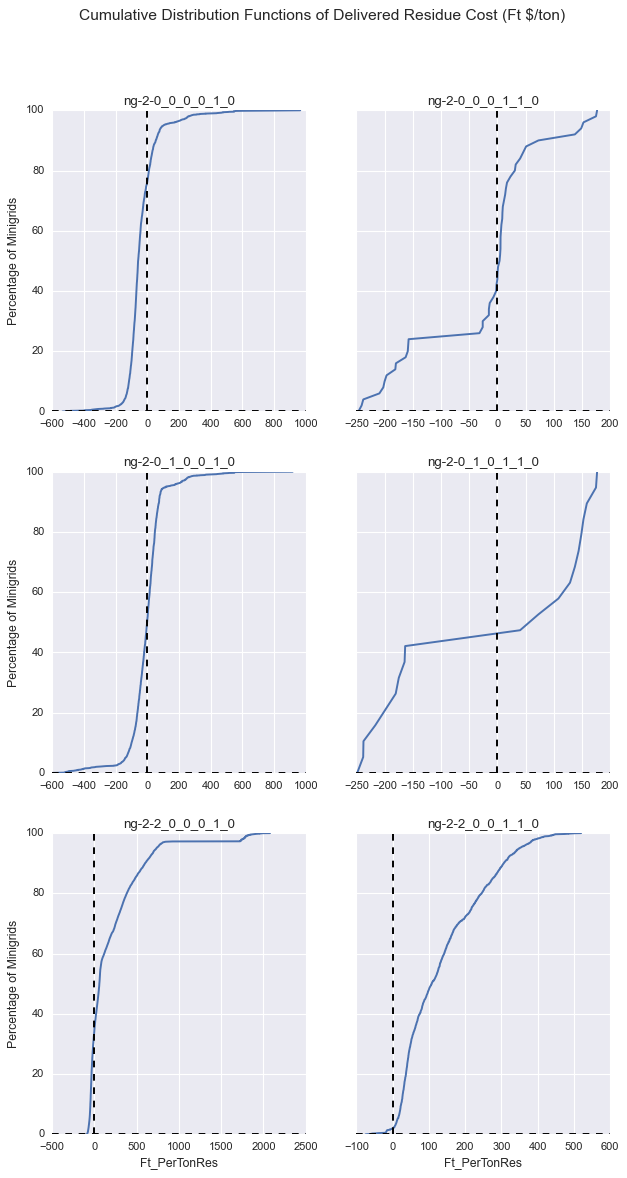

In [5]:
plt.style.use('seaborn')

df = pd.read_csv('CDF1.csv')
cdfCol = df.columns
figure, axis = plt.subplots(3, 2, figsize=(9,16),sharey=True)

df.plot('ng-2-0_0_0_0_1_0','ng-2-0_0_0_0_1_0-cum', ax= axis[0,0])
#sns.scatterplot(data=df, x='ng-2-0_0_0_0_1_0', y='ng-2-0_0_0_0_1_0-cum', s=20, alpha=0.2, hue='Tier', ax=axis[0,0])
axis[0,0].set(title='ng-2-0_0_0_0_1_0')
axis[0,0].axvline(0, c='black', ls='--') 
axis[0,0].axhline(0, c='black', ls='--')
axis[0,0].get_legend().set_visible(False) 
axis[0,0].set(xlabel=None)

df.plot('ng-2-0_0_0_1_1_0','ng-2-0_0_0_1_1_0-cum', ax= axis[0,1])
axis[0,1].set(title='ng-2-0_0_0_1_1_0')
axis[0,1].axvline(0, c='black', ls='--') 
axis[0,1].axhline(0, c='black', ls='--') 
axis[0,1].get_legend().set_visible(False)
axis[0,1].set(xlabel=None)

df.plot('ng-2-0_1_0_0_1_0','ng-2-0_1_0_0_1_0-cum', ax= axis[1,0])
axis[1,0].set(title='ng-2-0_1_0_0_1_0')
axis[1,0].axvline(0, c='black', ls='--') 
axis[1,0].axhline(0, c='black', ls='--')
axis[1,0].get_legend().set_visible(False) 
axis[1,0].set(xlabel=None)

df.plot('ng-2-0_1_0_1_1_0','ng-2-0_1_0_1_1_0-cum', ax= axis[1,1])
axis[1,1].set(title='ng-2-0_1_0_1_1_0')
axis[1,1].axvline(0, c='black', ls='--') 
axis[1,1].axhline(0, c='black', ls='--')
axis[1,1].get_legend().set_visible(False) 
axis[1,1].set(xlabel=None)

df.plot('ng-2-2_0_0_0_1_0','ng-2-2_0_0_0_1_0-cum', ax= axis[2,0])
axis[2,0].set(title='ng-2-2_0_0_0_1_0')
axis[2,0].axvline(0, c='black', ls='--') 
axis[2,0].axhline(0, c='black', ls='--')
axis[2,0].get_legend().set_visible(False) 
axis[2,0].set(xlabel=None)

df.plot('ng-2-2_0_0_1_1_0','ng-2-2_0_0_1_1_0-cum', ax= axis[2,1])
axis[2,1].set(title='ng-2-2_0_0_1_1_0')
axis[2,1].axvline(0, c='black', ls='--') 
axis[2,1].axhline(0, c='black', ls='--')
axis[2,1].get_legend().set_visible(False)
axis[2,1].set(xlabel=None)

    
figure.suptitle('Cumulative Distribution Functions of Delivered Residue Cost (Ft $/ton)', fontsize=14)
#figure.supxlabel('Ft_PerTonRes', fontsize= 14)
#figure.supylabel('Percentage of Minigrids', fontsize=14)

plt.setp(axis[-1, :], xlabel='Ft_PerTonRes')
plt.setp(axis[:, 0], ylabel='Percentage of Minigrids')
plt.show()

## comment
The Cummulative distribution curves highlights to us which scenario has the highest proportion of minigrids which bioenergy can potentially play a role (the determining threshold in this case is the zero mark).

## Plotting the Delivered Feedstock Price vs LCOE 

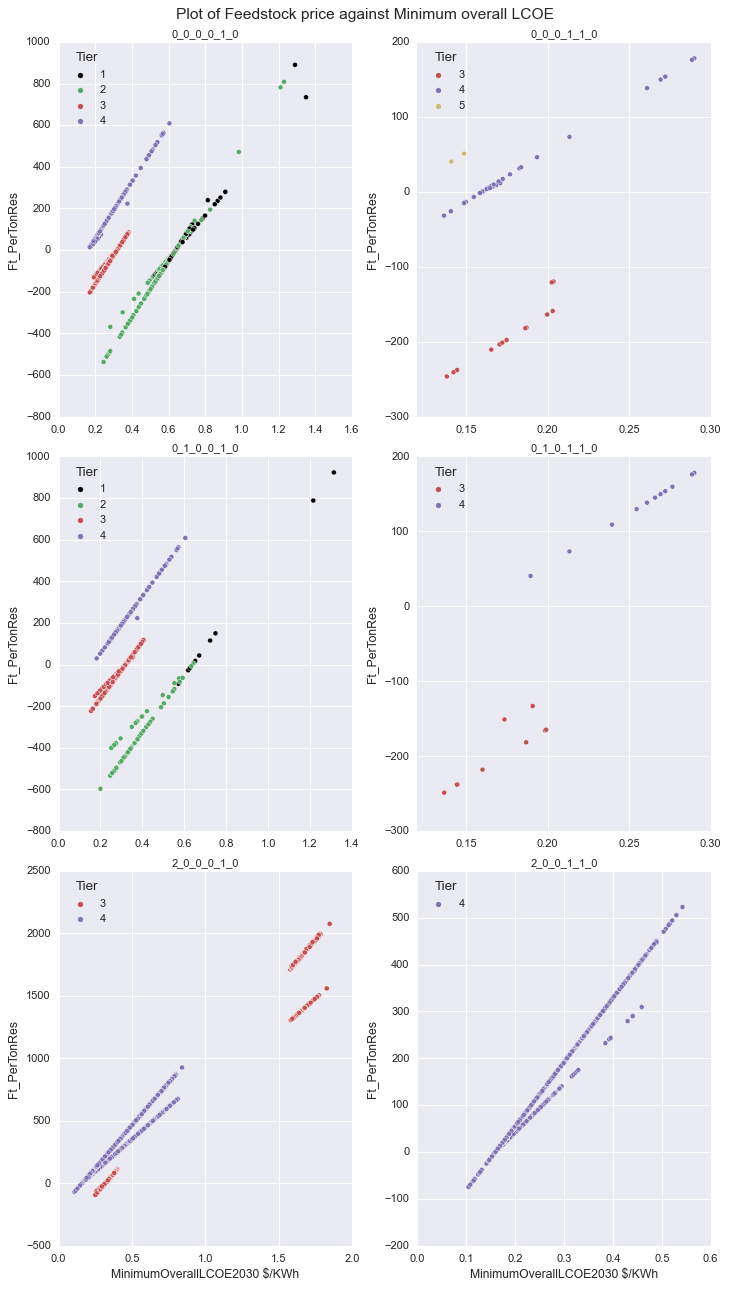

In [6]:
plt.style.use('seaborn')
figure, axis = plt.subplots(3, 2, figsize=(9,16),layout='constrained')
count = 0

palette ={1: "k", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        if count%2 == 0:
            sns.scatterplot(x='MinimumOverallLCOE2030',y='Ft_PerTonRes', hue = 'Tier', ax = axis[count//2,0], data=df, palette=palette)
            axis[count//2,0].set_title(scenario.split('-')[2], fontsize=10)
            axis[count//2,0].legend(title='Tier',loc='upper left')
            axis[count//2,0].set(xlabel=None)
        
        elif count == 3:
            sns.scatterplot(x='MinimumOverallLCOE2030',y='Ft_PerTonRes',  hue = 'Tier', ax = axis[1, 1],data=df, palette=palette)
            axis[1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[1, 1].legend(title='Tier',loc='upper left')
            axis[1, 1].set(xlabel=None)
            
        elif count == 5:
            sns.scatterplot(x='MinimumOverallLCOE2030',y='Ft_PerTonRes', hue = 'Tier', ax = axis[2, 1], data=df, palette=palette)
            axis[2, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[2, 1].legend(title='Tier',loc='upper left')
            axis[2, 1].set(xlabel=None)
            
        else:
            sns.scatterplot(x='MinimumOverallLCOE2030',y='Ft_PerTonRes', hue='Tier', ax = axis[(count%2)-1, 1], data=df, palette=palette)
            axis[(count%2)-1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[(count%2)-1, 1].legend(title='Tier',loc='upper left')
            axis[(count%2)-1, 1].set(xlabel=None)
            
        count+=1
    
figure.suptitle('Plot of Feedstock price against Minimum overall LCOE', fontsize=14)
plt.setp(axis[-1, :], xlabel='MinimumOverallLCOE2030 $/KWh')
plt.setp(axis[:, 0], ylabel='Ft_PerTonRes')
plt.show()

The graphs above gives us a hint as to what value of Levelised cost of electrification does bioenergy offer some level of competition, given different tiers of access in the selected scenarios. Simply put, depending on the tier of access, clusters with higher LCOE prove to be more suitable for bio-electrification. This is especially true for Tier 4 and 5. However, in general, there is a positive linear relationship between the feedstock price and LCOE.
#### Take note of the LCOE values for different tiers :
should bioenergy be viable under different tiers

Tier 1: > 0.64 $/KWh

Tier 2: > 0.64 $/KWh

Tier 3: > 0.32 $/KWh

Tier 4: > 0.16 $/KWh

Tier 5: > 0.148 $/KW



## Plotting Delivered feedstock price against Energy demand

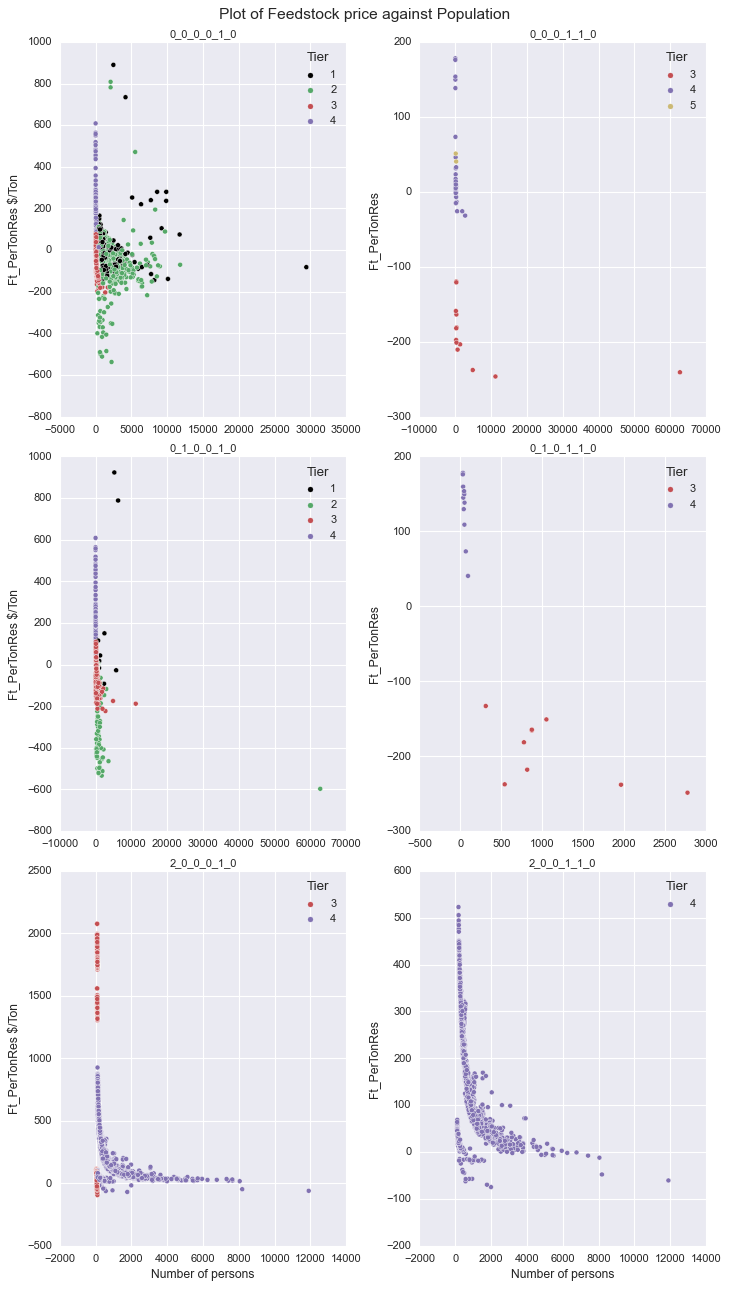

In [7]:
plt.style.use('seaborn')
figure, axis = plt.subplots(3, 2, figsize=(9,16),layout='constrained')
count = 0

palette ={1: "k", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        if count%2 == 0:
            sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier', ax = axis[count//2,0], data=df, palette=palette)
            axis[count//2,0].set_title(scenario.split('-')[2], fontsize=10)
            axis[count//2,0].legend(title='Tier',loc='upper right')
            axis[count//2,0].set(xlabel=None)
        
        elif count == 3:
            sns.scatterplot(x='Pop2030',y='Ft_PerTonRes',  hue = 'Tier', ax = axis[1, 1],data=df, palette=palette)
            axis[1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[1, 1].legend(title='Tier',loc='upper right')
            axis[1, 1].set(xlabel=None)
            
        elif count == 5:
            sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier', ax = axis[2, 1], data=df, palette=palette)
            axis[2, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[2, 1].legend(title='Tier',loc='upper right')
            axis[2, 1].set(xlabel=None)
            
        else:
            sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue='Tier', ax = axis[(count%2)-1, 1], data=df, palette=palette)
            axis[(count%2)-1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[(count%2)-1, 1].legend(title='Tier',loc='upper right')
            axis[(count%2)-1, 1].set(xlabel=None)
            
        count+=1
    
figure.suptitle('Plot of Feedstock price against Population', fontsize=14)
plt.setp(axis[-1, :], xlabel='Number of persons')
plt.setp(axis[:, 0], ylabel='Ft_PerTonRes $/Ton')
plt.show()

## Plotting all points in a scatter plot

Based on sceanrio groupings

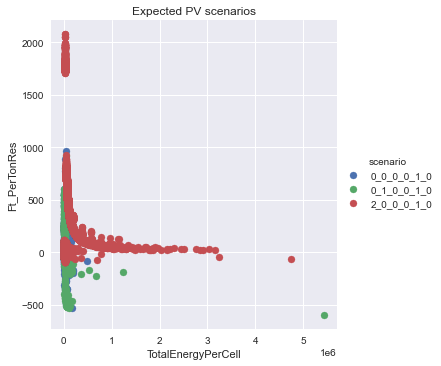

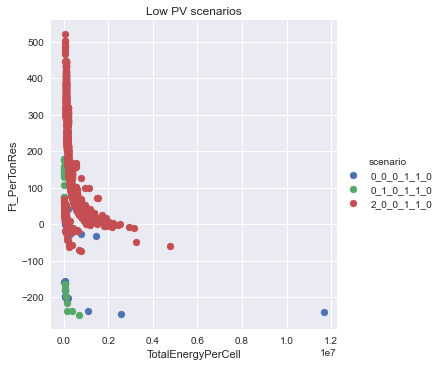

In [18]:
file=os.getcwd()+ '/final-results1.csv'
df = pd.read_csv(file)

df1 = df[(df.scenario == '0_1_0_0_1_0') | (df.scenario == '0_0_0_0_1_0') | (df.scenario == '2_0_0_0_1_0')]
df2 = df[(df.scenario == '0_1_0_1_1_0') | (df.scenario == '0_0_0_1_1_0') | (df.scenario == '2_0_0_1_1_0')]


sns.FacetGrid(df1,height=5, hue='scenario') \
           .map(plt.scatter, "TotalEnergyPerCell", "Ft_PerTonRes") \
           .add_legend().set(title='Expected PV scenarios')

sns.FacetGrid(df2,height=5, hue='scenario') \
           .map(plt.scatter, "TotalEnergyPerCell", "Ft_PerTonRes") \
           .add_legend().set(title='Low PV scenarios')

## Combining all scenarios into one file


In [7]:
path=os.getcwd()+ '/results'
df = pd.DataFrame()

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        data = pd.read_csv(file)
        
        data['scenario'] = [scenario.split('-')[2] for i in data['Ft_PerTonRes']]
        
        df = pd.concat([df, data], axis=0)

df.to_csv('final-results1.csv', index=False)


## Analysing duplicates across scenarios using ID's

In [302]:
file=os.getcwd()+ '/final-results1.csv'
df = pd.read_csv(file)


In [303]:
ids = df['id']

# Check and extract duplicate
dp_df = df[ids.isin(ids[ids.duplicated()])].sort_values("id")

# Counting duplicates
duplicates = dp_df.pivot_table(index = ['id'], aggfunc ='size')
duplicates

unique_dp = dp_df.drop_duplicates(subset=['id'])
unique_dp['idCount'] = duplicates.values

dp_df

,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,MinimumOverall2030,MinimumOverallLCOE2030,...,CapFactor,GasifierCap,investment,NpvIt,NpvGen,NpvOM,NpvFt,Ft,Ft_PerTonRes,scenario
734,0.086,5.027,10.750,604,Kebbi,872.5,13923.323,2,MG_PV_Hybrid2030,0.6020,...,0.166667,31.788409,68345.078653,63873.905283,1.622566e+05,39823.252945,-6010.443811,-515.759292,-38.277591,0_0_0_0_1_0
26082,0.086,5.027,10.750,604,Kebbi,872.5,342569.280,4,MG_PV_Hybrid2030,0.2295,...,0.666667,195.530411,420390.383562,392888.208936,3.992160e+06,244952.715109,278328.515132,23883.513837,72.042744,2_0_0_1_1_0
26081,0.164,4.900,10.734,1308,Kebbi,1404.0,551089.750,4,MG_PV_Hybrid2030,0.1990,...,0.666667,314.548944,676280.229737,632037.597885,6.422170e+06,394054.395453,251756.821567,21603.383069,40.507913,2_0_0_1_1_0
732,0.164,4.900,10.734,1308,Kebbi,1404.0,22398.390,2,MG_PV_Hybrid2030,0.5960,...,0.166667,51.137877,109946.434932,102753.677506,2.610215e+05,64063.496231,-11198.398040,-960.940328,-44.332279,0_0_0_0_1_0
3769,0.044,8.280,10.120,2697,Kaduna,135.8,22483.795,3,MG_PV_Hybrid2030,0.2727,...,0.333333,25.666433,55182.830194,51572.738499,2.620168e+05,32153.885084,-12273.318433,-1053.179803,-64.017028,0_1_0_0_1_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26101,0.035,6.890,6.984,720261,Kogi,228.8,89802.860,4,MG_PV_Hybrid2030,0.4658,...,0.666667,51.257340,110203.281393,102993.720928,1.046525e+06,64213.155311,320285.772256,27483.887772,418.264110,2_0_0_1_1_0
7888,0.105,7.703,7.080,720398,Benue,313.0,122899.680,4,MG_PV_Hybrid2030,0.4070,...,0.666667,70.148219,150818.671233,140952.029190,1.432222e+06,87878.896502,354058.107426,30381.909320,337.852326,2_0_0_0_1_0
25856,0.105,7.703,7.080,720398,Benue,313.0,122899.680,4,MG_PV_Hybrid2030,0.3860,...,0.666667,70.148219,150818.671233,140952.029190,1.432222e+06,87878.896502,323987.047529,27801.496117,309.157664,2_0_0_1_1_0
22908,0.087,5.645,10.055,720625,Niger,410.2,152832.700,4,MG_PV_Hybrid2030,0.3613,...,0.666667,87.233276,187551.543950,175281.816775,1.781049e+06,109282.375881,358978.751941,30804.152371,275.458120,2_0_0_0_1_0


In [209]:
# Dropping duplicate id's

df_dropped = df[~df['id'].isin(duplicates.index)]
df_dropped.to_csv('non-duplicates.csv', index=False)

In [229]:
## Write to file duplicate zones
dp_df.to_csv('duplicates.csv', index=False) # contains duplicates

In [292]:
# unique_dp[(unique_dp.idCount >1)]
unique_dp_scenarios = dp_df.groupby('id')['scenario'].unique()

## Adding the scenarios to duplicate ids
# unique_dp['scenario']= [','.join(arr) for arr in unique_dp_scenarios]

## Adding residue prices Ft_PerTonRes
unique_dp_prices = dp_df.groupby('id')['Ft_PerTonRes'].unique()

# duplicates[(duplicates.values > 3)],
unique_dp_scenarios



unique_dp_df = unique_dp_prices.to_frame()
unique_dp_df['idCount'] = duplicates.values
unique_dp_df

,Ft_PerTonRes,idCount
id,,
604,"[-38.277591382334464, 72.04274406927011]",2
1308,"[40.50791334482894, -44.3322788814273]",2
2697,"[-64.01702783036754, 785.2888492435941, 68.923...",3
2745,"[370.5508935765759, 338.18598472725915]",2
2961,"[-117.9678784299472, 53.57992979412734]",2
...,...,...
720213,"[221.07172693230885, 249.76638838634224]",2
720257,"[212.39659672527543, 241.0912581793089]",2
720261,"[446.6251123151762, 418.26410971525945]",2


In [265]:
maxFtPerTonRes = []
posFtCount = []

for i, val in enumerate(unique_dp_prices):
    ftCount = 0
    
    maxFtPerTonRes.append(max(val))
    
    for value in val:
        if value >= 0:
            ftCount+=1
    if 
    posFtCount.append(ftCount)        

unique_dp['maxFtPerTonRes'] = maxFtPerTonRes
unique_dp['posFtCount'] = posFtCount
unique_dp['Ft_PerTonRes'] = unique_dp_prices.values


In [266]:
# unique duplicates with count number and max feedstock price

unique_dp.drop('scenario', axis=1, inplace=True)

unique_dp


,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,MinimumOverall2030,MinimumOverallLCOE2030,...,investment,NpvIt,NpvGen,NpvOM,NpvFt,Ft,Ft_PerTonRes,idCount,maxFtPerTonRes,posFtCount
734,0.086,5.027,10.750,604,Kebbi,872.5,13923.323,2,MG_PV_Hybrid2030,0.6020,...,68345.078653,63873.905283,1.622566e+05,39823.252945,-6010.443811,-515.759292,"[-38.277591382334464, 72.04274406927011]",2,72.042744,1
26081,0.164,4.900,10.734,1308,Kebbi,1404.0,551089.750,4,MG_PV_Hybrid2030,0.1990,...,676280.229737,632037.597885,6.422170e+06,394054.395453,251756.821567,21603.383069,"[40.50791334482894, -44.3322788814273]",2,40.507913,1
3769,0.044,8.280,10.120,2697,Kaduna,135.8,22483.795,3,MG_PV_Hybrid2030,0.2727,...,55182.830194,51572.738499,2.620168e+05,32153.885084,-12273.318433,-1053.179803,"[-64.01702783036754, 785.2888492435941, 68.923...",3,785.288849,2
22857,0.052,6.184,10.130,2745,Niger,296.8,110604.210,4,MG_PV_Hybrid2030,0.4310,...,135730.052226,126850.516099,1.288935e+06,79087.072670,349475.231627,29988.650377,"[370.5508935765759, 338.18598472725915]",2,370.550894,2
660,0.233,10.470,10.130,2961,Bauchi,2150.0,34304.004,2,MG_PV_Hybrid2030,0.5522,...,168387.234247,157371.246959,3.997646e+05,98115.732022,-34718.560115,-2979.217600,"[-117.9678784299472, 53.57992979412734]",2,53.579930,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25693,0.088,8.630,7.035,720213,Benue,425.5,167099.730,4,MG_PV_Hybrid2030,0.3215,...,205059.600171,191644.486141,1.947311e+06,119483.955355,314996.574043,27030.018937,"[221.07172693230885, 249.76638838634224]",2,249.766388,2
25694,0.105,8.290,7.023,720257,Benue,428.0,168091.770,4,MG_PV_Hybrid2030,0.3152,...,206277.000856,192782.243791,1.958871e+06,120193.309362,304432.407650,26123.502355,"[212.39659672527543, 241.0912581793089]",2,241.091258,2
12901,0.035,6.890,6.984,720261,Kogi,228.8,89802.860,4,MG_PV_Hybrid2030,0.4866,...,110203.281393,102993.720928,1.046525e+06,64213.155311,342003.212047,29347.472512,"[446.6251123151762, 418.26410971525945]",2,446.625112,2
7888,0.105,7.703,7.080,720398,Benue,313.0,122899.680,4,MG_PV_Hybrid2030,0.4070,...,150818.671233,140952.029190,1.432222e+06,87878.896502,354058.107426,30381.909320,"[337.85232587314266, 309.15766441910927]",2,337.852326,2


In [267]:
# write file of unique duplicates with Max feedstock price
unique_dp.to_csv('unique-duplicates.csv', index=False)

#Combining non-duplicates and unique-duplicates works for the feedstock price map

## Getting counts of positive feedstock prices for duplicates

In [306]:
# Remove negatives from duplicate dataframe
filtered_dp_df = dp_df[dp_df['Ft_PerTonRes'] >= 0]


# Counting duplicates by the id
positive_dp = filtered_dp_df.pivot_table(index = ['id'], aggfunc ='size')

positive_dp

id
604       1
1308      1
2697      2
2745      2
2961      1
         ..
720213    2
720257    2
720261    2
720398    2
720625    2
Length: 2335, dtype: int64

In [308]:
# Get unique positive duplicates
unique_pos_dp = filtered_dp_df.drop_duplicates(subset=['id'])

# Add positive Ft count to the dataFrame
unique_pos_dp['posFtCount'] = positive_dp.values

unique_pos_dp.drop(['scenario','Ft', 'NpvFt'], axis=1, inplace=True)
unique_pos_dp

,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,MinimumOverall2030,MinimumOverallLCOE2030,...,CropLandArea,CultivationArea,CapFactor,GasifierCap,investment,NpvIt,NpvGen,NpvOM,Ft_PerTonRes,posFtCount
26082,0.086,5.027,10.750,604,Kebbi,872.5,342569.280,4,MG_PV_Hybrid2030,0.2295,...,192.594705,385.189410,0.666667,195.530411,4.203904e+05,392888.208936,3.992160e+06,244952.715109,72.042744,1
26081,0.164,4.900,10.734,1308,Kebbi,1404.0,551089.750,4,MG_PV_Hybrid2030,0.1990,...,309.826286,619.652572,0.666667,314.548944,6.762802e+05,632037.597885,6.422170e+06,394054.395453,40.507913,1
16665,0.044,8.280,10.120,2697,Kaduna,135.8,50558.105,4,MG_PV_Hybrid2030,0.7344,...,24.289788,48.579575,0.666667,28.857366,6.204334e+04,57984.426743,5.891831e+05,36151.359195,785.288849,2
22857,0.052,6.184,10.130,2745,Niger,296.8,110604.210,4,MG_PV_Hybrid2030,0.4310,...,53.137925,106.275850,0.666667,63.130257,1.357301e+05,126850.516099,1.288935e+06,79087.072670,370.550894,2
12016,0.233,10.470,10.130,2961,Bauchi,2150.0,844015.300,4,MG_PV_Hybrid2030,0.1992,...,496.986983,993.973965,0.666667,481.743893,1.035749e+06,967990.064759,9.835803e+06,603509.571344,53.579930,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25693,0.088,8.630,7.035,720213,Benue,425.5,167099.730,4,MG_PV_Hybrid2030,0.3215,...,80.280243,160.560487,0.666667,95.376558,2.050596e+05,191644.486141,1.947311e+06,119483.955355,221.071727,2
25694,0.105,8.290,7.023,720257,Benue,428.0,168091.770,4,MG_PV_Hybrid2030,0.3152,...,80.756852,161.513704,0.666667,95.942791,2.062770e+05,192782.243791,1.958871e+06,120193.309362,212.396597,2
12901,0.035,6.890,6.984,720261,Kogi,228.8,89802.860,4,MG_PV_Hybrid2030,0.4866,...,43.144268,86.288535,0.666667,51.257340,1.102033e+05,102993.720928,1.046525e+06,64213.155311,446.625112,2
7888,0.105,7.703,7.080,720398,Benue,313.0,122899.680,4,MG_PV_Hybrid2030,0.4070,...,59.045076,118.090152,0.666667,70.148219,1.508187e+05,140952.029190,1.432222e+06,87878.896502,337.852326,2


In [309]:
# write file of unique duplicates with positive feedstock price

unique_pos_dp.to_csv('unique-pos-duplicates.csv', index=False)

In [301]:
#unique_dp_df.iloc[[0]]['idCount'].values

array([2])

In [191]:
unique_dp[(unique_dp.idCount == 3)]

# Getting duplicate Ids greater than 3
dp4_keys = duplicates[(duplicates.values > 3)].keys()
dp4_df = dp_df[dp_df['id'].isin(dp4_keys)]
dp4_df 

,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,MinimumOverall2030,MinimumOverallLCOE2030,...,CapFactor,GasifierCap,investment,NpvIt,NpvGen,NpvOM,NpvFt,Ft,Ft_PerTonRes,scenario
26823,0.362,8.25,10.090,24982,Kaduna,2238.0,834208.750,4,MG_PV_Hybrid2030,0.1816,...,0.666667,476.146547,1.023715e+06,956743.061334,9.721521e+06,596497.439233,212582.660023,18241.828006,29.885204,2_0_0_1_1_0
1412,0.362,8.25,10.090,24982,Kaduna,2238.0,164066.330,2,MG_PV_Hybrid2030,0.2456,...,0.166667,374.580662,8.053484e+05,752662.078052,1.911961e+06,469259.742046,-752333.834955,-64558.155490,-537.767129,0_0_0_0_1_0
3771,0.362,8.25,10.090,24982,Kaduna,2238.0,82232.320,2,MG_PV_Hybrid2030,0.3408,...,0.166667,187.745023,4.036518e+05,377244.672044,9.583012e+05,235199.490785,-285835.654831,-24527.705377,-407.640175,0_1_0_0_1_0
16681,0.362,8.25,10.090,24982,Kaduna,2238.0,834208.750,4,MG_PV_Hybrid2030,0.2026,...,0.666667,476.146547,1.023715e+06,956743.061334,9.721521e+06,596497.439233,416696.627510,35756.953125,58.579865,2_0_0_0_1_0
18100,0.188,10.52,12.530,173965,Jigawa,1535.0,542094.750,4,MG_PV_Hybrid2030,0.2188,...,0.666667,309.414812,6.652418e+05,621721.350499,6.317346e+06,387622.558738,372575.585054,31970.903653,60.942484,2_0_0_0_1_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,0.035,8.65,4.957,682790,Cross River,188.5,16333.103,3,MG_PV_Hybrid2030,0.3394,...,0.333333,18.645095,4.008695e+04,37464.442720,1.903392e+05,23357.832471,3770.364549,323.536932,27.071839,0_1_0_0_1_0
4911,0.018,7.64,5.484,684132,Abia,32.0,12894.822,4,MG_PV_Hybrid2030,0.2900,...,0.666667,7.360058,1.582413e+04,14788.902029,1.502709e+05,9220.387945,19575.135398,1679.752493,178.029735,0_1_0_1_1_0
2404,0.018,7.64,5.484,684132,Abia,32.0,12894.822,4,MG_PV_Hybrid2030,0.2900,...,0.666667,7.360058,1.582413e+04,14788.902029,1.502709e+05,9220.387945,19575.135398,1679.752493,178.029735,0_0_0_1_1_0
620,0.018,7.64,5.484,684132,Abia,32.0,12894.822,4,MG_PV_Hybrid2030,0.3162,...,0.666667,7.360058,1.582413e+04,14788.902029,1.502709e+05,9220.387945,23500.668660,2016.604532,213.731232,0_0_0_0_1_0


In [110]:
## Plot using the duplicates
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.dpi'] = 100
dp4_df = dp4_df.reset_index(drop=True)
pivot_df = dp4_df.pivot(index=['id','Tier', 'Admin1'], columns='scenario', values='Ft_PerTonRes').fillna(0)
dp4_df.pivot(index=['id','Tier','Admin1'], columns='scenario', values='Ft_PerTonRes').fillna(0)

scenario                 0_0_0_0_1_0  0_0_0_1_1_0  0_1_0_0_1_0  0_1_0_1_1_0  \
id     Tier Admin1                                                            
24982  2    Kaduna       -534.488061     0.000000  -405.154565     0.000000   
       4    Kaduna          0.000000     0.000000     0.000000     0.000000   
173965 2    Jigawa          0.000000     0.000000  -526.529076     0.000000   
       3    Jigawa       -169.083223     0.000000     0.000000     0.000000   
       4    Jigawa          0.000000     0.000000     0.000000     0.000000   
211583 3    Borno           0.000000     0.000000  -175.384086     0.000000   
       4    Borno          20.417495     0.000000     0.000000     0.000000   
216936 2    Borno           0.000000     0.000000  -533.493188     0.000000   
       3    Borno        -179.363578     0.000000     0.000000     0.000000   
       4    Borno           0.000000     0.000000     0.000000     0.000000   
273672 3    Kwara        -149.517386     0.000000   -60.310437     0.000000   
       4    Kwara           0.000000     0.000000     0.000000     0.000000   
287520 3    Kwara        -162.616548     0.000000   -86.508760     0.000000   
       4    Kwara           0.000000     0.000000     0.000000     0.000000   
295788 3    Kwara        -130.283174     0.000000   -10.566784     0.000000   
       4    Kwara           0.000000     0.000000     0.000000     0.000000   
310009 3    Kwara        -120.500256     0.000000     9.993925     0.000000   
       4    Kwara           0.000000     0.000000     0.000000     0.000000   
327188 3    Oyo          -123.816499     0.000000   -42.071097     0.000000   
       4    Oyo             0.000000     0.000000     0.000000     0.000000   
369713 3    Kogi         -166.761853     0.000000   -95.130993     0.000000   
       4    Kogi            0.000000     0.000000     0.000000     0.000000   
370369 3    Oyo           -94.467745     0.000000    13.641793     0.000000   
       4    Oyo             0.000000     0.000000     0.000000     0.000000   
372014 3    Kogi         -165.103731     0.000000   -91.814750     0.000000   
       4    Kogi            0.000000     0.000000     0.000000     0.000000   
408658 3    Kogi         -153.331066     0.000000   -82.529268     0.000000   
       4    Kogi            0.000000     0.000000     0.000000     0.000000   
408718 3    Kogi         -103.089978     0.000000    10.657174     0.000000   
       4    Kogi            0.000000     0.000000     0.000000     0.000000   
509136 3    Bayelsa       -58.320691     0.000000    47.799101     0.000000   
       4    Bayelsa         0.000000     0.000000     0.000000     0.000000   
510951 4    Taraba         26.884170    -1.635524    67.176528     0.000000   
573685 3    Ogun          -96.457491     0.000000    35.529000     0.000000   
       4    Ogun            0.000000     0.000000     0.000000     0.000000   
589470 1    Kogi            0.000000     0.000000   -15.827579     0.000000   
       2    Kogi         -334.186954     0.000000     0.000000     0.000000   
       4    Kogi            0.000000     0.000000     0.000000     0.000000   
627662 4    Lagos         188.551040   152.735610   188.551040   152.735610   
673350 3    Cross River   -75.896781     0.000000    78.640166     0.000000   
       4    Cross River     0.000000     0.000000     0.000000     0.000000   
675334 3    Bayelsa      -117.018200  -157.476371   -51.356579     0.000000   
       4    Bayelsa         0.000000     0.000000     0.000000     0.000000   
677838 3    Cross River   -47.045463     0.000000    86.599150     0.000000   
       4    Cross River     0.000000     0.000000     0.000000     0.000000   
678343 3    Bayelsa       -83.855765     0.000000    34.202503     0.000000   
       4    Bayelsa         0.000000     0.000000     0.000000     0.000000   
681347 3    Rivers          0.000000     0.000000     0.000000     0.000000   
       4    Rivers        173.627944   137.480890 

Text(0, 0.5, 'Feedstock price  $/ton')

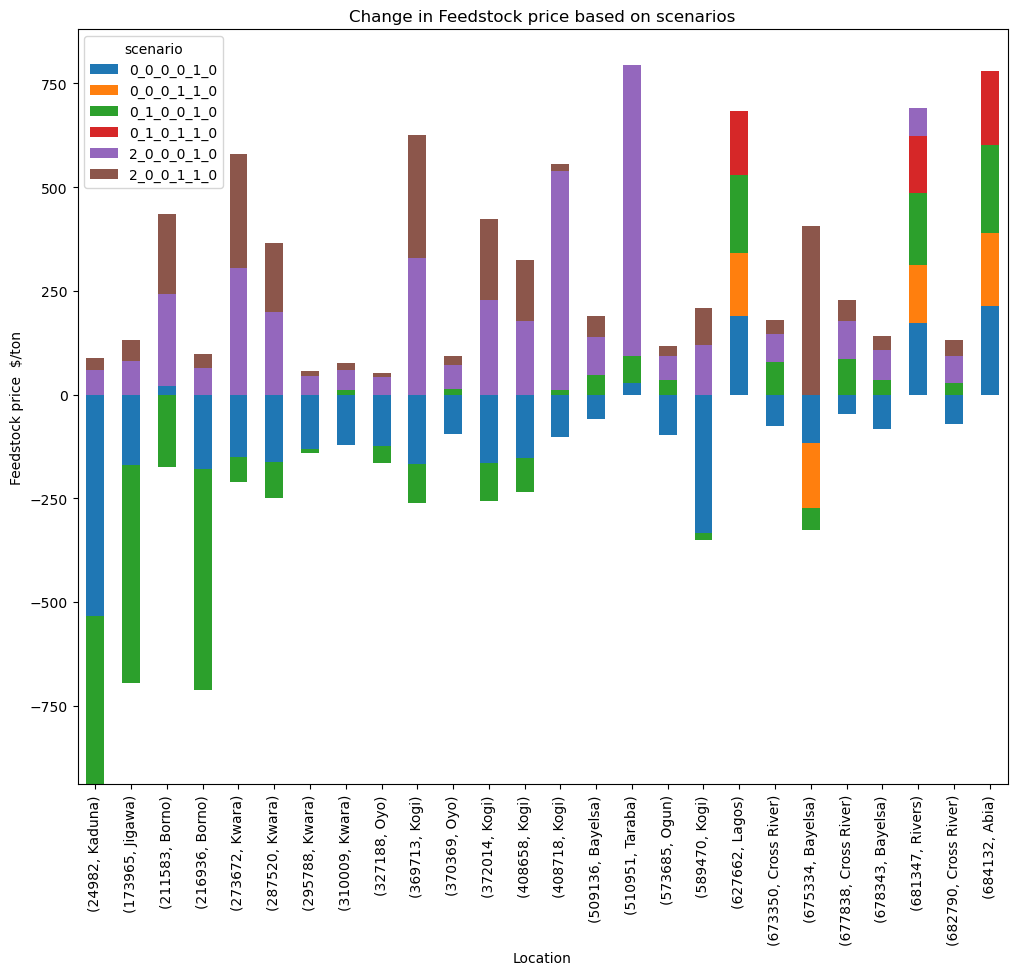

In [97]:
pivot_df.plot(kind='bar', stacked=True)
plt.title('Change in Feedstock price based on scenarios')
plt.xlabel('Location')
plt.ylabel('Feedstock price  $/ton')

## Proportion of Ft_PerTonRes > 0

In [524]:
path=os.getcwd()+ '/results'

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        print(scenario)
        
        
        df1 = df[(df.Ft_PerTonRes > 0)]
        
        print(df1.Tier.value_counts())
        print(df1[["Ft_PerTonRes","MinimumOverallLCOE2030","TotalEnergyPerCell","Pop2030"]].describe())
        

ng-2-0_0_0_0_1_0-results
2    276
4    146
1     96
3     56
Name: Tier, dtype: int64
       Ft_PerTonRes  MinimumOverallLCOE2030  TotalEnergyPerCell       Pop2030
count    574.000000              574.000000          574.000000    574.000000
mean      87.044792                0.551551        22950.836125    900.031716
std      127.033969                0.190028        27288.046965   1363.089087
min        0.045472                0.170000         4091.272000     10.530000
25%       18.275352                0.354000        10814.640000    113.470000
50%       39.106294                0.647250        13823.684500    710.250000
75%       83.195602                0.666875        21104.519000   1042.750000
max      889.625449                1.350000       285464.780000  11736.000000
ng-2-0_0_0_1_1_0-results
4    27
5     2
Name: Tier, dtype: int64
       Ft_PerTonRes  MinimumOverallLCOE2030  TotalEnergyPerCell     Pop2030
count     29.000000               29.000000           29.000000   29.0

## Splitting duplicates into Low PV and Estimated PV category

In [111]:
low_PV_pivot = pivot_df.drop(columns=['0_1_0_0_1_0', '0_0_0_0_1_0','2_0_0_0_1_0'])
low_PV_pivot 

scenario                 0_0_0_1_1_0  0_1_0_1_1_0  2_0_0_1_1_0
id     Tier Admin1                                            
24982  2    Kaduna          0.000000     0.000000     0.000000
       4    Kaduna          0.000000     0.000000    29.702977
173965 2    Jigawa          0.000000     0.000000     0.000000
       3    Jigawa          0.000000     0.000000     0.000000
       4    Jigawa          0.000000     0.000000    51.755996
211583 3    Borno           0.000000     0.000000     0.000000
       4    Borno           0.000000     0.000000   192.862156
216936 2    Borno           0.000000     0.000000     0.000000
       3    Borno           0.000000     0.000000     0.000000
       4    Borno           0.000000     0.000000    34.511530
273672 3    Kwara           0.000000     0.000000     0.000000
       4    Kwara           0.000000     0.000000   273.446873
287520 3    Kwara           0.000000     0.000000     0.000000
       4    Kwara           0.000000     0.000000   166.995457
295788 3    Kwara           0.000000     0.000000     0.000000
       4    Kwara           0.000000     0.000000    12.126886
310009 3    Kwara           0.000000     0.000000     0.000000
       4    Kwara           0.000000     0.000000    16.769627
327188 3    Oyo             0.000000     0.000000     0.000000
       4    Oyo             0.000000     0.000000     9.473891
369713 3    Kogi            0.000000     0.000000     0.000000
       4    Kogi            0.000000     0.000000   296.328953
370369 3    Oyo             0.000000     0.000000     0.000000
       4    Oyo             0.000000     0.000000    23.236302
372014 3    Kogi            0.000000     0.000000     0.000000
       4    Kogi            0.000000     0.000000   195.515151
408658 3    Kogi            0.000000     0.000000     0.000000
       4    Kogi            0.000000     0.000000   148.092869
408718 3    Kogi            0.000000     0.000000     0.000000
       4    Kogi            0.000000     0.000000    15.940566
509136 3    Bayelsa         0.000000     0.000000     0.000000
       4    Bayelsa         0.000000     0.000000    49.434625
510951 4    Taraba         -1.635524     0.000000     0.000000
573685 3    Ogun            0.000000     0.000000     0.000000
       4    Ogun            0.000000     0.000000    22.738865
589470 1    Kogi            0.000000     0.000000     0.000000
       2    Kogi            0.000000     0.000000     0.000000
       4    Kogi            0.000000     0.000000    90.224420
627662 4    Lagos         152.735610   152.735610     0.000000
673350 3    Cross River     0.000000     0.000000     0.000000
       4    Cross River     0.000000     0.000000    32.355971
675334 3    Bayelsa      -157.476371     0.000000     0.000000
       4    Bayelsa         0.000000     0.000000   406.759861
677838 3    Cross River     0.000000     0.000000     0.000000
       4    Cross River     0.000000     0.000000    50.926935
678343 3    Bayelsa         0.000000     0.000000     0.000000
       4    Bayelsa         0.000000     0.000000    34.014093
681347 3    Rivers          0.000000     0.000000     0.000000
       4    Rivers        137.480890   137.480890     0.000000
682790 3    Cross River     0.000000     0.000000     0.000000
       4    Cross River     0.000000     0.000000    38.159398
684132 4    Abia          176.944188   176.944188     0.000000

## Violin Plot

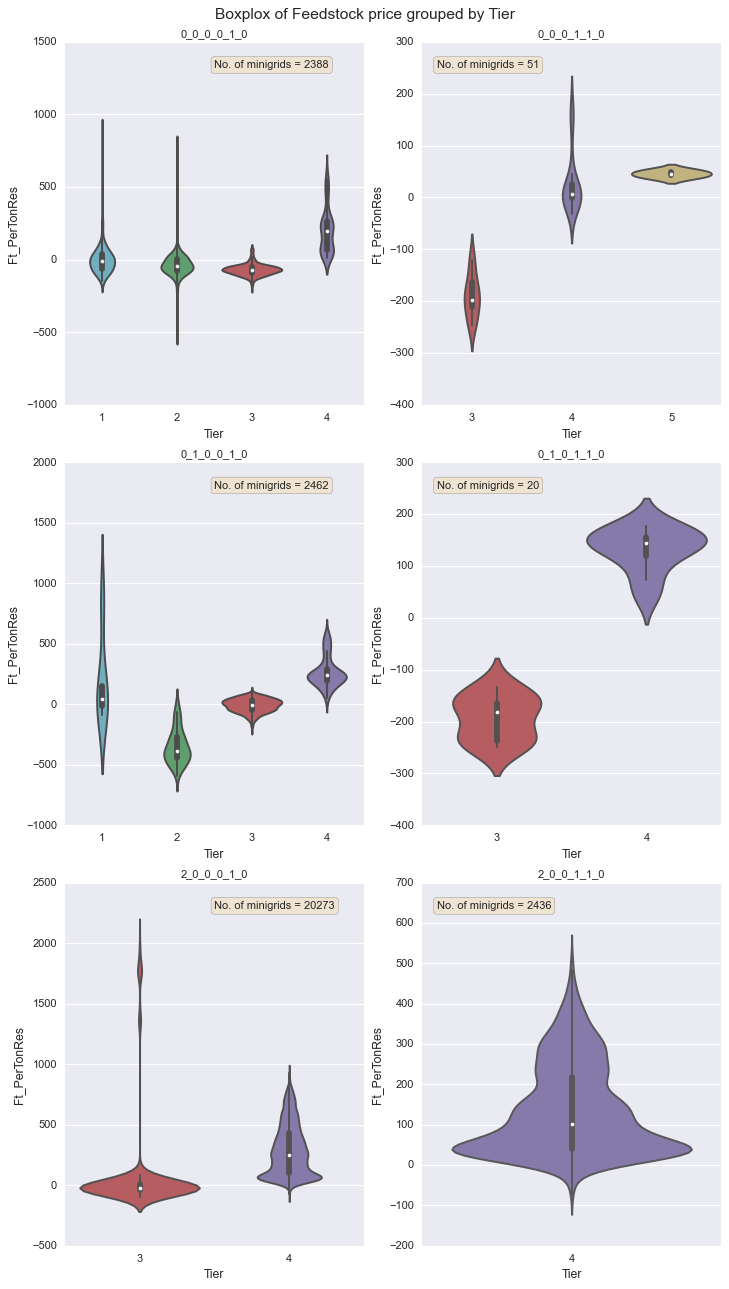

In [8]:
counter = 0
# Initialise the subplot function using number of rows and columns
plt.style.use('seaborn') 
figure, axis = plt.subplots(3, 2, figsize=(9,16),layout='constrained')
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        textstr = f'No. of minigrids = {len(df)}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        
        if counter == 0:
            sns.violinplot(data=df, y='Ft_PerTonRes', x='Tier',ax = axis[counter,0],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[counter,0].set_title(scenario.split('-')[2], fontsize=10)
            axis[counter,0].text(0.5, 0.95, textstr, transform=axis[counter,0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
        
        elif counter%2 == 0:
            sns.violinplot(data=df, y='Ft_PerTonRes', x='Tier',ax = axis[counter//2,0],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter//2,0])
            axis[counter//2,0].set_title(scenario.split('-')[2], fontsize=10)    
            axis[counter//2,0].text(0.5, 0.95, textstr, transform=axis[counter//2,0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
        elif counter == 3:
            sns.violinplot(data=df, y='Ft_PerTonRes', x='Tier',ax = axis[1, 1],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[1, 1])
            axis[1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[1,1].text(0.05, 0.95, textstr, transform=axis[1,1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
        elif counter == 5:
            sns.violinplot(data=df, y='Ft_PerTonRes', x='Tier', ax = axis[2, 1],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[2, 1])
            axis[2, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[2,1].text(0.05, 0.95, textstr, transform=axis[2,1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
        else:
            sns.violinplot(data=df, y='Ft_PerTonRes', x='Tier', ax = axis[(counter%2)-1, 1],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[(counter%2)-1, 1])
            axis[(counter%2)-1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[(counter%2)-1, 1].text(0.05, 0.95, textstr, transform=axis[(counter%2)-1, 1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
          
        counter+=1
    
figure.suptitle('Boxplox of Feedstock price grouped by Tier', fontsize=14)
plt.show()

## Plotting CDF with Tier

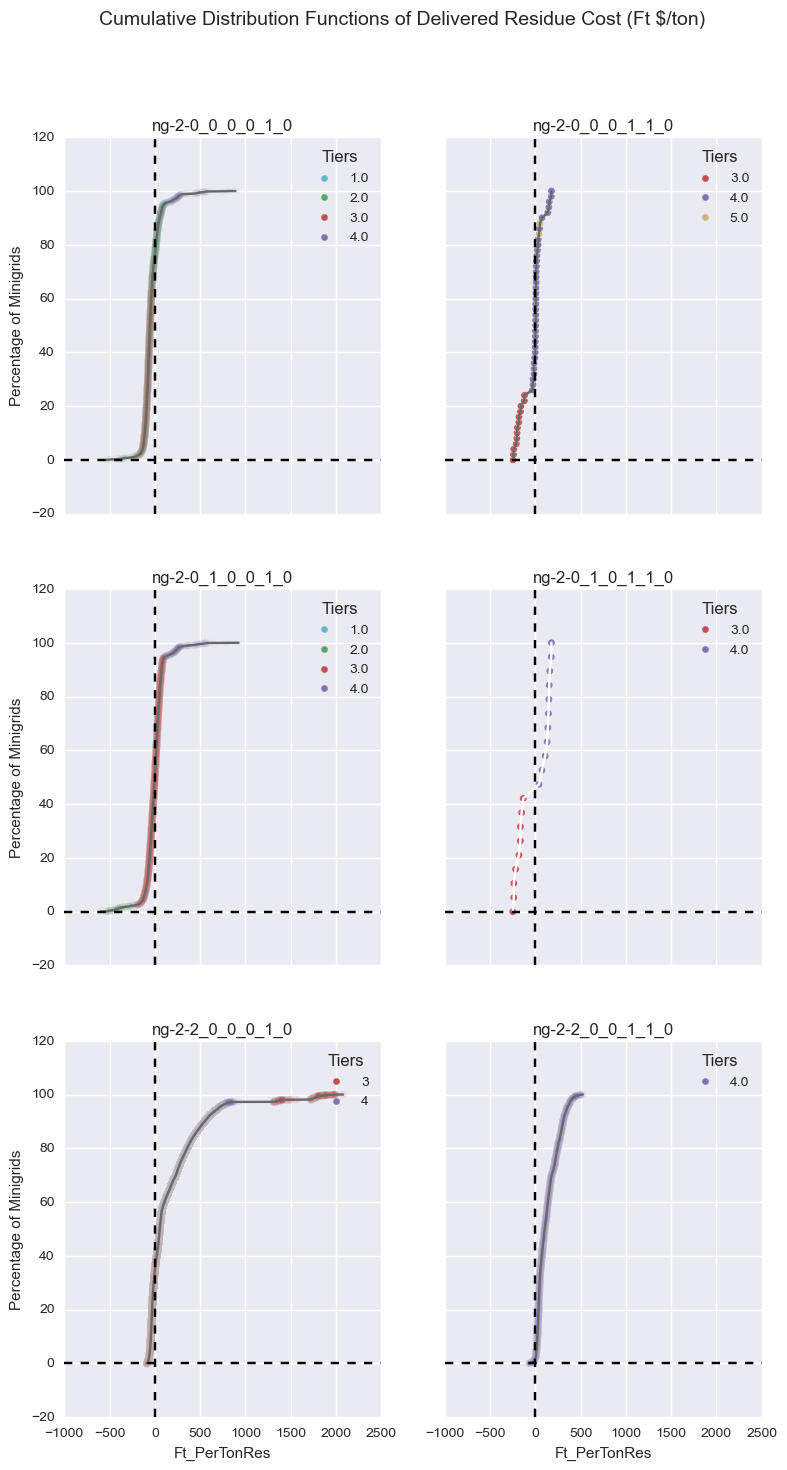

In [10]:
#bmh
plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('CDF.csv')
cdfCol = df.columns
figure, axis = plt.subplots(3, 2, figsize=(9,16),sharey=True, sharex=True)

sns.lineplot(data=df, x='ng-2-0_0_0_0_1_0',y='ng-2-0_0_0_0_1_0-cum', ax= axis[0,0], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_0_0_0_1_0', y='ng-2-0_0_0_0_1_0-cum', s=30, alpha=0.04, hue='ng-2-0_0_0_0_1_0-tier', ax=axis[0,0], palette=palette)
axis[0,0].set(title='ng-2-0_0_0_0_1_0')
axis[0,0].axvline(0, c='black', ls='--') 
axis[0,0].axhline(0, c='black', ls='--')
axis[0,0].get_legend().set_visible(True)
axis[0,0].legend(title='Tiers')
axis[0,0].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-0_0_0_1_1_0',y='ng-2-0_0_0_1_1_0-cum', ax= axis[0,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_0_0_1_1_0', y='ng-2-0_0_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-2-0_0_0_1_1_0-tier', ax=axis[0,1],palette=palette)
axis[0,1].set(title='ng-2-0_0_0_1_1_0')
axis[0,1].axvline(0, c='black', ls='--') 
axis[0,1].axhline(0, c='black', ls='--') 
axis[0,1].get_legend().set_visible(True)
axis[0,1].legend(title='Tiers')
axis[0,1].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-0_1_0_0_1_0',y='ng-2-0_1_0_0_1_0-cum', ax= axis[1,0], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_1_0_0_1_0', y='ng-2-0_1_0_0_1_0-cum', s=30, alpha=0.05, hue='ng-2-0_1_0_0_1_0-tier', ax=axis[1,0],palette=palette)
axis[1,0].set(title='ng-2-0_1_0_0_1_0')
axis[1,0].axvline(0, c='black', ls='--') 
axis[1,0].axhline(0, c='black', ls='--')
axis[1,0].get_legend().set_visible(True)
axis[1,0].legend(title='Tiers')
axis[1,0].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-0_1_0_1_1_0', y='ng-2-0_1_0_1_1_0-cum', ax= axis[1,1], color='white')
sns.scatterplot(data=df, x='ng-2-0_1_0_1_1_0', y='ng-2-0_1_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-2-0_1_0_1_1_0-tier', ax=axis[1,1],palette=palette)
axis[1,1].set(title='ng-2-0_1_0_1_1_0')
axis[1,1].axvline(0, c='black', ls='--') 
axis[1,1].axhline(0, c='black', ls='--')
axis[1,1].get_legend().set_visible(True)
axis[1,1].legend(title='Tiers')
axis[1,1].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-2_0_0_0_1_0',y='ng-2-2_0_0_0_1_0-cum', ax= axis[2,0], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-2_0_0_0_1_0', y='ng-2-2_0_0_0_1_0-cum', s=30, alpha=0.05, hue='ng-2-2_0_0_0_1_0-tier', ax=axis[2,0],palette=palette)
axis[2,0].set(title='ng-2-2_0_0_0_1_0')
axis[2,0].axvline(0, c='black', ls='--') 
axis[2,0].axhline(0, c='black', ls='--')
axis[2,0].get_legend().set_visible(True)
axis[2,0].legend(title='Tiers')
axis[2,0].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-2_0_0_1_1_0',y='ng-2-2_0_0_1_1_0-cum', ax= axis[2,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-2_0_0_1_1_0', y='ng-2-2_0_0_1_1_0-cum', s=30, alpha=0.09, hue='ng-2-2_0_0_1_1_0-tier', ax=axis[2,1],palette=palette)
axis[2,1].set(title='ng-2-2_0_0_1_1_0')
axis[2,1].axvline(0, c='black', ls='--') 
axis[2,1].axhline(0, c='black', ls='--')
axis[2,1].get_legend().set_visible(True)
axis[2,1].legend(title='Tiers')
axis[2,1].set(xlabel=None)

    
figure.suptitle('Cumulative Distribution Functions of Delivered Residue Cost (Ft $/ton)', fontsize=14)
#figure.supxlabel('Ft_PerTonRes', fontsize= 14)
#figure.supylabel('Percentage of Minigrids', fontsize=14)

'''
lines = [] 
labels = []

#set legend
for ax in figure.axes: 
    Line, Label = ax.get_legend_handles_labels() 
    print(Label)
    lines.extend(Line) 
    labels.extend(Label) 


figure.legend(lines, labels, loc='upper right') 
'''
sns.despine()
plt.setp(axis[-1, :], xlabel='Ft_PerTonRes')
plt.setp(axis[:, 0], ylabel='Percentage of Minigrids')
plt.show()

## Final Plots

In [19]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ng-2-0_0_0_0_1_0-results
ng-2-0_0_0_1_1_0-results
ng-2-0_1_0_0_1_0-results
ng-2-0_1_0_1_1_0-results
ng-2-2_0_0_0_1_0-results
ng-2-2_0_0_1_1_0-results


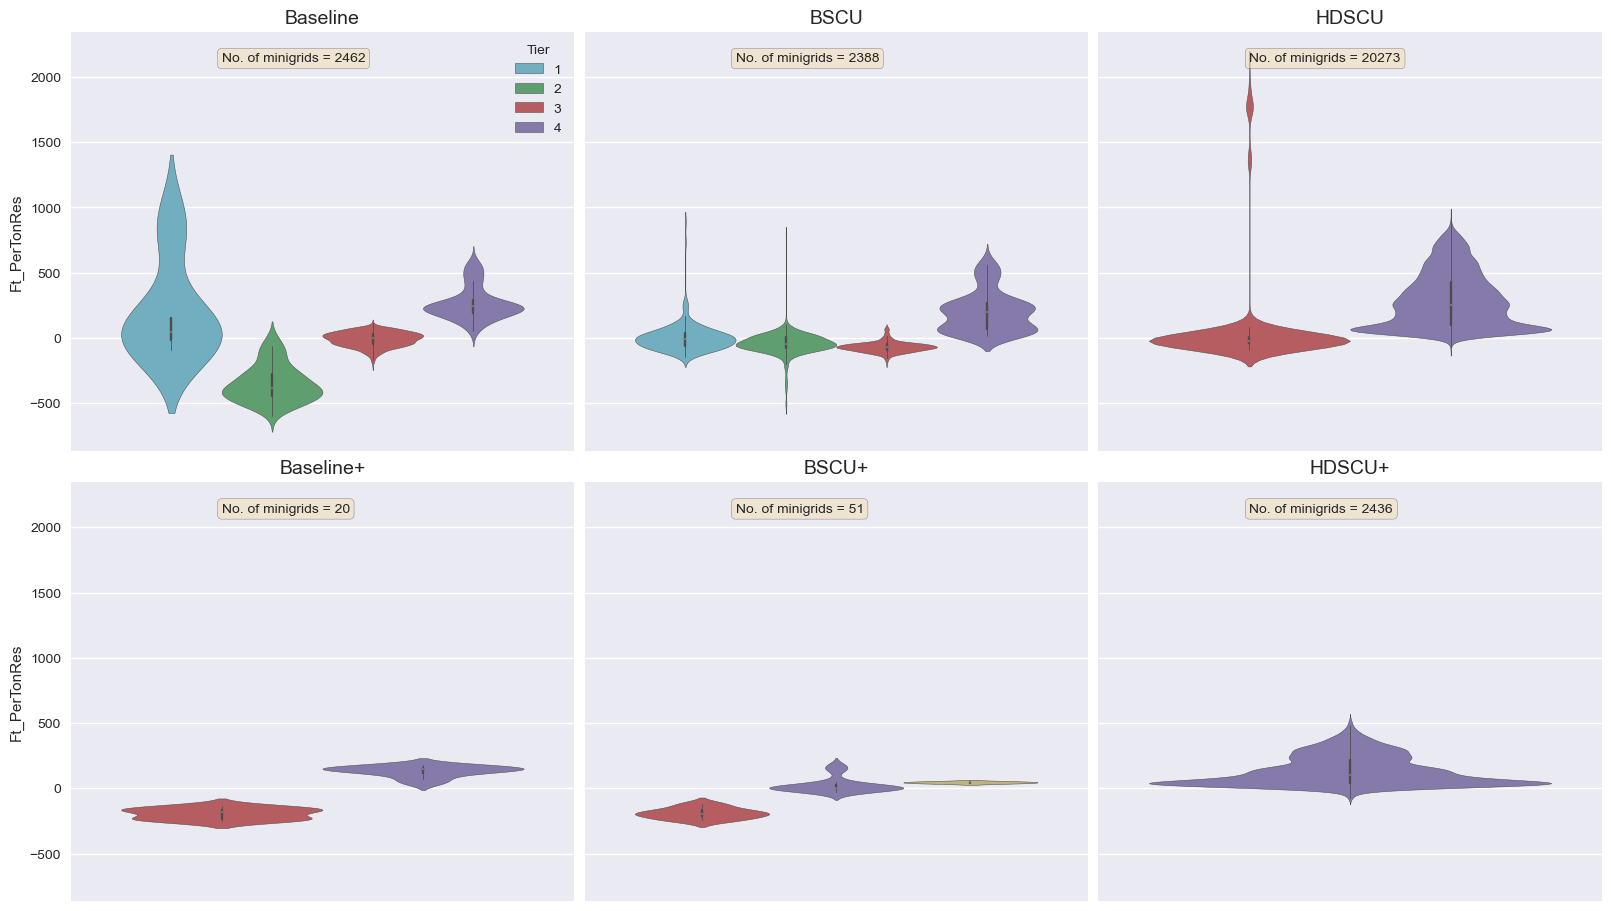

In [ ]:

path=os.getcwd()+ '/results'

plt.style.use('seaborn') 
figure, axis = plt.subplots(2, 3, figsize=(16,9),layout='constrained', sharey=True)
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        textstr = f'No. of minigrids = {len(df)}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        print(scenario)     
        
        if scenario == 'ng-2-0_1_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,0],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,0].text(0.3, 0.95, textstr, transform=axis[0,0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            axis[0,0].set_title('Baseline', fontsize=14)
            axis[0,0].set(xlabel=None)
            
            
        elif scenario == 'ng-2-0_1_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,0],palette=palette, legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,0].text(0.3, 0.95, textstr, transform=axis[1,0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            axis[1,0].set_title('Baseline-L', fontsize=14)
        
        elif scenario == 'ng-2-0_0_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,1],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,1].text(0.3, 0.95, textstr, transform=axis[0,1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            axis[0,1].set_title('BSCU', fontsize=14)
            axis[0,1].set(xlabel=None)
            
        elif scenario == 'ng-2-0_0_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,1],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,1].text(0.3, 0.95, textstr, transform=axis[1,1].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            axis[1,1].set_title('BSCU-L', fontsize=14)
            
        elif scenario == 'ng-2-2_0_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,2],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,2].text(0.3, 0.95, textstr, transform=axis[0,2].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            axis[0,2].set_title('HDSCU', fontsize=14)
            axis[0,2].set(xlabel=None)
            
        elif scenario == 'ng-2-2_0_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,2],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,2].text(0.3, 0.95, textstr, transform=axis[1,2].transAxes, fontsize=10, verticalalignment='top', bbox=props)
            axis[1,2].set_title('HDSCU-L', fontsize=14)
sns.despine()

plt.setp(axis[:, 0], ylabel='Ft_PerTonRes')
plt.show()

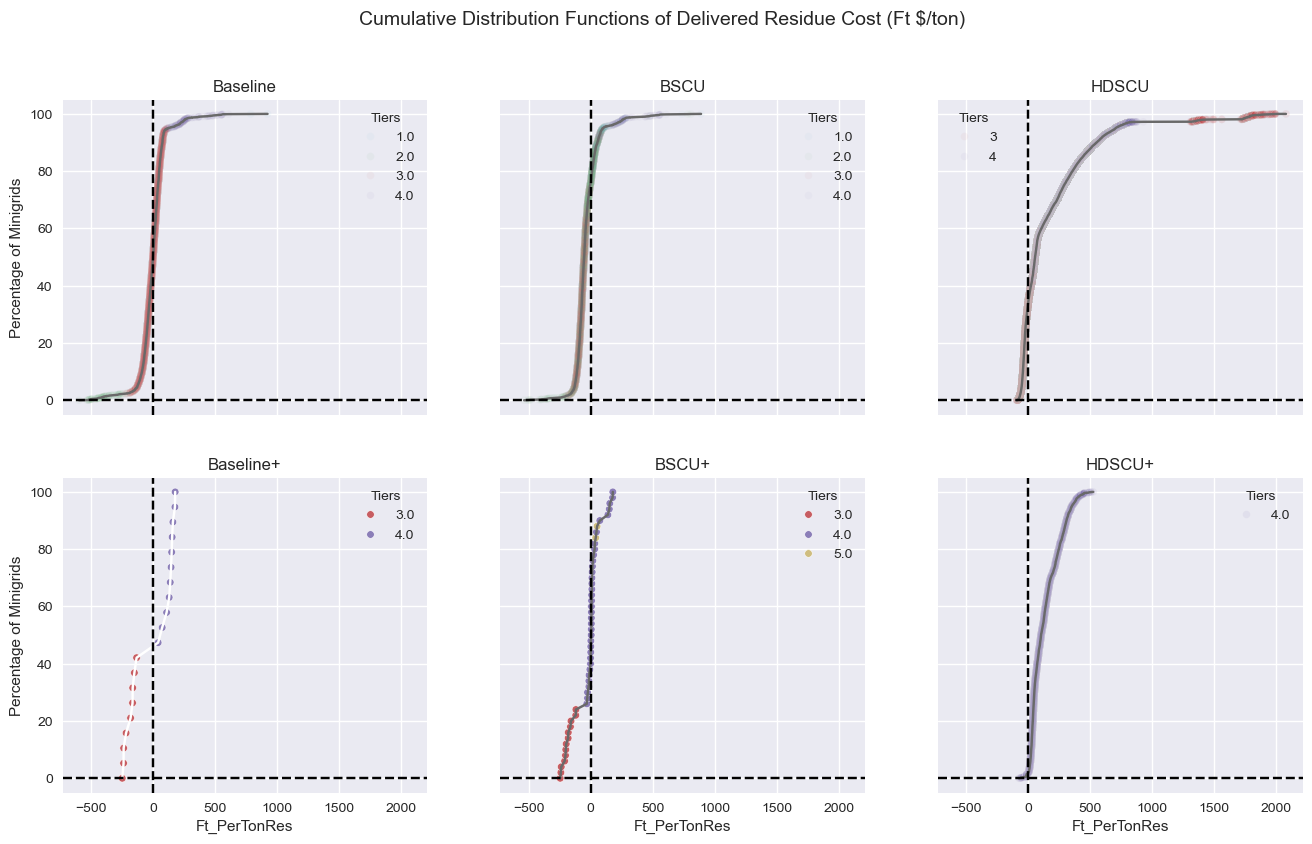

In [45]:
plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('CDF.csv')
cdfCol = df.columns
figure, axis = plt.subplots(2, 3, figsize=(16,9),sharey=True, sharex=True)

sns.lineplot(data=df, x='ng-2-0_0_0_0_1_0',y='ng-2-0_0_0_0_1_0-cum', ax= axis[0,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_0_0_0_1_0', y='ng-2-0_0_0_0_1_0-cum', s=30, alpha=0.04, hue='ng-2-0_0_0_0_1_0-tier', ax=axis[0,1], palette=palette)
axis[0,1].set(title='BSCU')
axis[0,1].axvline(0, c='black', ls='--') 
axis[0,1].axhline(0, c='black', ls='--')
axis[0,1].get_legend().set_visible(True)
axis[0,1].legend(title='Tiers')
axis[0,1].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-0_0_0_1_1_0',y='ng-2-0_0_0_1_1_0-cum', ax= axis[1,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_0_0_1_1_0', y='ng-2-0_0_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-2-0_0_0_1_1_0-tier', ax=axis[1,1],palette=palette)
axis[1,1].set(title='BSCU+')
axis[1,1].axvline(0, c='black', ls='--') 
axis[1,1].axhline(0, c='black', ls='--') 
axis[1,1].get_legend().set_visible(True)
axis[1,1].legend(title='Tiers')
axis[1,1].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-0_1_0_0_1_0',y='ng-2-0_1_0_0_1_0-cum', ax= axis[0,0], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_1_0_0_1_0', y='ng-2-0_1_0_0_1_0-cum', s=30, alpha=0.05, hue='ng-2-0_1_0_0_1_0-tier', ax=axis[0,0],palette=palette)
axis[0,0].set(title='Baseline')
axis[0,0].axvline(0, c='black', ls='--') 
axis[0,0].axhline(0, c='black', ls='--')
axis[0,0].get_legend().set_visible(True)
axis[0,0].legend(title='Tiers')
axis[0,0].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-0_1_0_1_1_0', y='ng-2-0_1_0_1_1_0-cum', ax= axis[1,0], color='white')
sns.scatterplot(data=df, x='ng-2-0_1_0_1_1_0', y='ng-2-0_1_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-2-0_1_0_1_1_0-tier', ax=axis[1,0],palette=palette)
axis[1,0].set(title='Baseline+')
axis[1,0].axvline(0, c='black', ls='--') 
axis[1,0].axhline(0, c='black', ls='--')
axis[1,0].get_legend().set_visible(True)
axis[1,0].legend(title='Tiers')
axis[1,0].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-2_0_0_0_1_0',y='ng-2-2_0_0_0_1_0-cum', ax= axis[0,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-2_0_0_0_1_0', y='ng-2-2_0_0_0_1_0-cum', s=30, alpha=0.05, hue='ng-2-2_0_0_0_1_0-tier', ax=axis[0,2],palette=palette)
axis[0,2].set(title='HDSCU')
axis[0,2].axvline(0, c='black', ls='--') 
axis[0,2].axhline(0, c='black', ls='--')
axis[0,2].get_legend().set_visible(True)
axis[0,2].legend(title='Tiers')
axis[0,2].set(xlabel=None)

sns.lineplot(data=df, x='ng-2-2_0_0_1_1_0',y='ng-2-2_0_0_1_1_0-cum', ax= axis[1,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-2_0_0_1_1_0', y='ng-2-2_0_0_1_1_0-cum', s=30, alpha=0.09, hue='ng-2-2_0_0_1_1_0-tier', ax=axis[1,2],palette=palette)
axis[1,2].set(title='HDSCU+')
axis[1,2].axvline(0, c='black', ls='--') 
axis[1,2].axhline(0, c='black', ls='--')
axis[1,2].get_legend().set_visible(True)
axis[1,2].legend(title='Tiers')
axis[1,2].set(xlabel=None)

    
figure.suptitle('Cumulative Distribution Functions of Delivered Residue Cost (Ft $/ton)', fontsize=14)
#figure.supxlabel('Ft_PerTonRes', fontsize= 14)
#figure.supylabel('Percentage of Minigrids', fontsize=14)

'''
lines = [] 
labels = []

#set legend
for ax in figure.axes: 
    Line, Label = ax.get_legend_handles_labels() 
    print(Label)
    lines.extend(Line) 
    labels.extend(Label) 


figure.legend(lines, labels, loc='upper right') 
'''
sns.despine()
plt.setp(axis[-1, :], xlabel='Ft_PerTonRes')
plt.setp(axis[:, 0], ylabel='Percentage of Minigrids')
plt.show()

## KDE

In [310]:
# Using the CDF values
# df = pd.read_csv('CDF.csv')
# KDE_df = df[df['ng-2-0_0_0_0_1_0'].notna()]['ng-2-0_0_0_0_1_0']

# KDE_df = pd.concat(
#     [
#     KDE_df,
#     df[df['ng-2-0_0_0_1_1_0'].notna()]['ng-2-0_0_0_1_1_0'],
#     df[df['ng-2-0_1_0_0_1_0'].notna()]['ng-2-0_1_0_0_1_0'],
#     df[df['ng-2-0_1_0_1_1_0'].notna()]['ng-2-0_1_0_1_1_0'],
#     df[df['ng-2-2_0_0_0_1_0'].notna()]['ng-2-2_0_0_0_1_0'],  
#     df[df['ng-2-2_0_0_1_1_0'].notna()]['ng-2-2_0_0_1_1_0'],
#     ])
# KDE_df = KDE_df.to_frame()
# KDE_df.columns = ['Ft_PerTonRes']




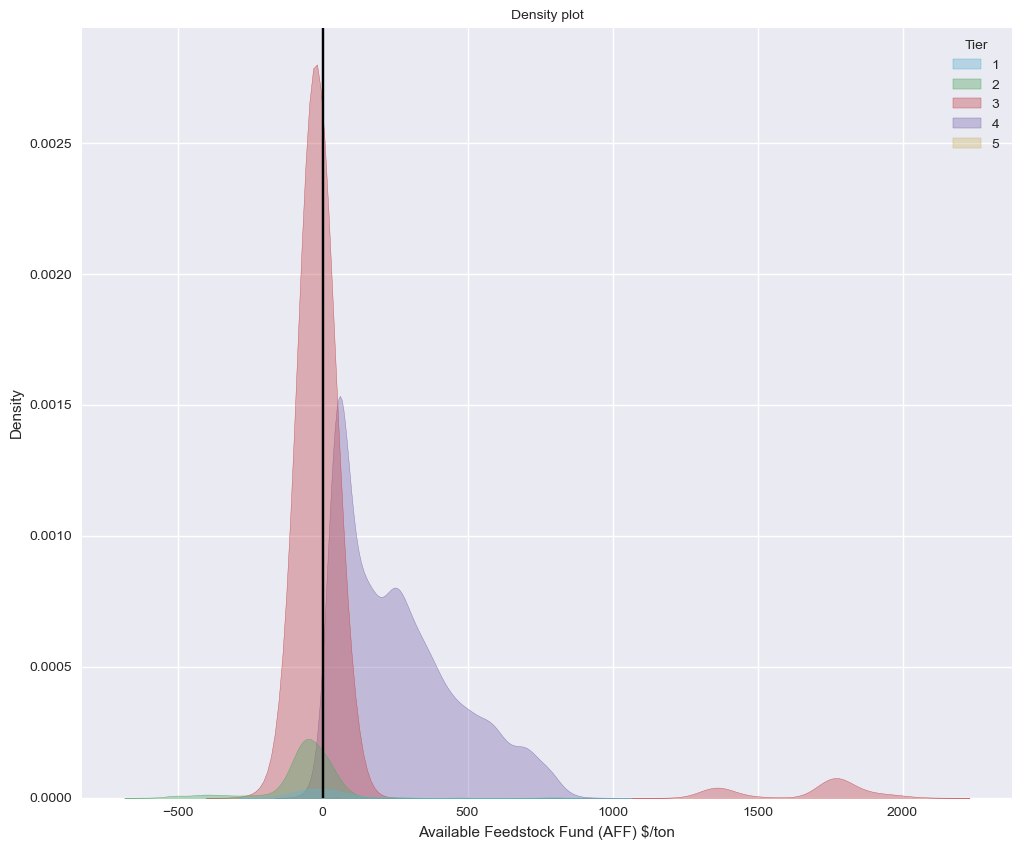

In [10]:
#  Using the final results df

df = pd.read_csv('final-results1.csv')
with sns.axes_style("darkgrid"):
    ax = sns.kdeplot(df,x='Ft_PerTonRes', hue='Tier' ,fill=True, alpha=0.4, palette=palette)
    ax.axvline(0, c='black', ls='-')
    # ax.axhline(0, c='black', ls='--')

plt.title('Density plot', fontsize=10)
ax.set(xlabel='Available Feedstock Fund (AFF) $/ton')
plt.show()




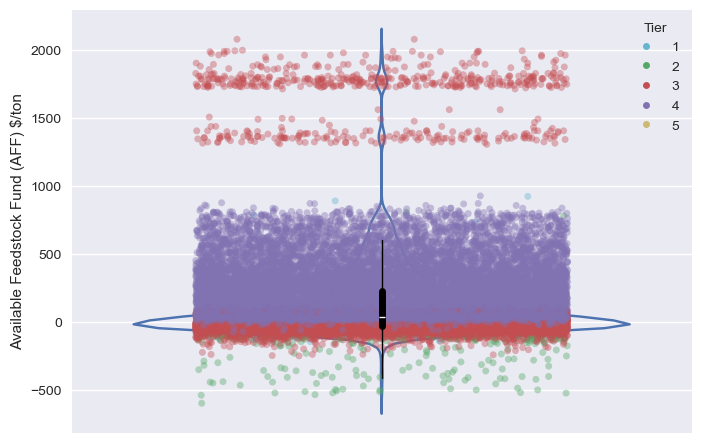

In [19]:
# Box Plot
df = pd.read_csv('final-results1.csv')

plt.style.use('seaborn-v0_8')

palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

# Create jittered version of "x" (which is only 0, 1, and 2)
#https://python-graph-gallery.com/web-ggbetweenstats-with-matplotlib/


df["all"] = ""
# ax = sns.violinplot(data=df[df.Tier == 1], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 2], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"),alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 3], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 4], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 5], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)

ax = sns.violinplot(data=df, y='Ft_PerTonRes',
                    inner_kws=dict(box_width=5, whis_width=1, color="black"), fill=False, native_scale=True)
ax.set_xlabel("")
ax.set_ylabel("Available Feedstock Fund (AFF) $/ton")
ax = sns.stripplot(y='Ft_PerTonRes', hue='Tier', data=df, 
                   zorder=1,
                jitter=0.3,alpha=0.4,palette=palette)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles, labels, loc='upper right', title='Tier',framealpha=0.9)

for handle in leg.legend_handles:
            handle.set_alpha(1.0)

plt.show()

## Fine tuning Minimum LCOE value for each Tiers

<AxesSubplot:xlabel='Pop2030', ylabel='MinimumOverallLCOE2030'>

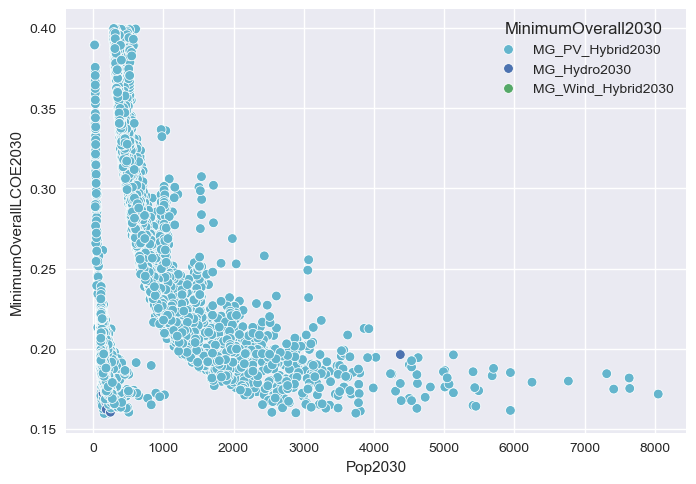

In [501]:
df = pd.read_csv('final-results1.csv')

plt.style.use('seaborn')

palette2 ={'MG_PV_Hybrid2030': "C5", 'MG_Hydro2030': "C6", "MG_Wind_Hybrid2030": "C7"}
    
sns.scatterplot(x='Pop2030',y='MinimumOverallLCOE2030', hue = 'MinimumOverall2030',data=df[(df.Ft_PerTonRes > 0) & (df.MinimumOverallLCOE2030 < 0.4) & (df.Tier == 4)], palette=palette2)

Bio-electrification systems in most cases was not suitable for replacing mini-grid hydro systems in clusters where the least cost technology was hydropower mini-grid (Even when Tier of access is level 4).

## Checking for population effect (what population is optimal for bioenergy???)


<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

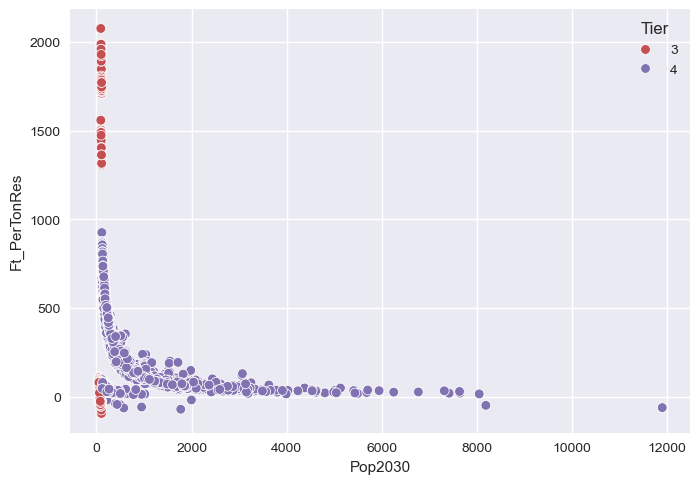

In [ ]:
## HDSCU scenario

df_test = df[df.scenario == '2_0_0_0_1_0']
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier',data=df_test, palette=palette)

# Notice!

The clusters below zero at a population less than 8000 are some Tier 3's and very little Tier 4's.


<AxesSubplot:xlabel='Pop2030', ylabel='MinimumOverallLCOE2030'>

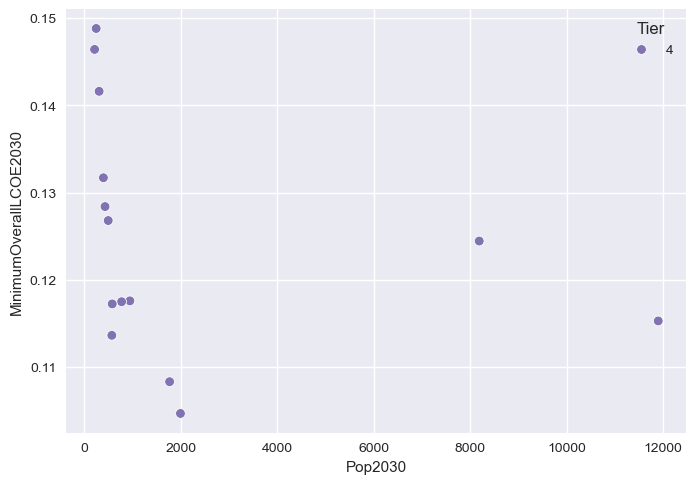

In [520]:
## Looking closer at the Feedstock prices below zero
# Added a different hue based on MinimumOverall2030 technology

df_test = df
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='MinimumOverallLCOE2030', hue = 'Tier', data=df_test[(df_test.Ft_PerTonRes < 0) & (df_test.MinimumOverall2030 == 'MG_Hydro2030')], palette=palette)



<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

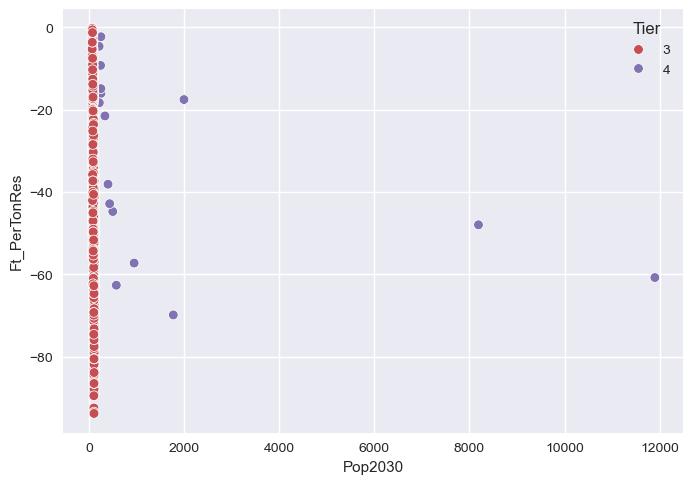

In [416]:
df_test = df[df.scenario == '2_0_0_0_1_0']
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier', data=df_test[df_test.Ft_PerTonRes < 0], palette=palette)


# Notice!

Comparing the two graphs above, you would notice that the Tier 3 systems overlaps with the Minigrid PV and Wind hybrid systems, while the Tier 4's overlaps with the Hydro minigrids.

It is clear from the three graphs above that at Tier 4, besides mini-grid hydro technolgies, bioenergy can be viable at a feedstock price above 0 $/Ton at a population less than 8000. This is significantly lesser at Tier 3.

let us have a look below

<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

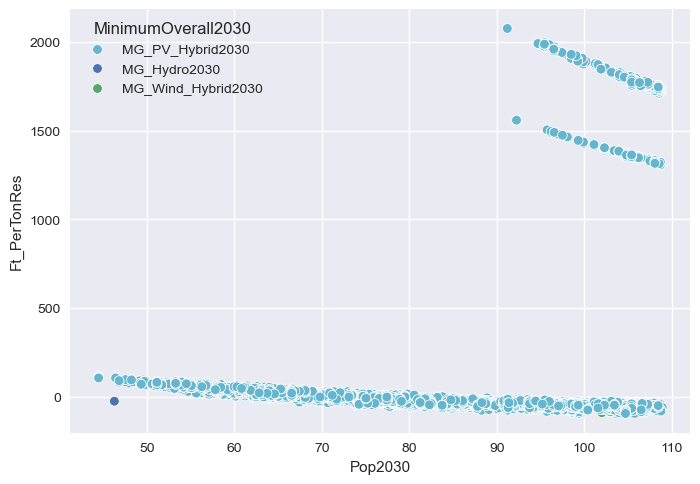

In [426]:
# considering only Tier 3 for the HDSCU scenario

df_test = df[df.scenario == '2_0_0_0_1_0']
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'MinimumOverall2030', data=df_test[(df_test.Tier == 3)], palette=palette2)


# Notice!
At Tier 3 the population limit becomes less than 60 persons for bioenergy to be viable under this particular scenario. However, there are some differences between the top and bottom of the graph (what I mentioned earlier was more applicable to the bottom). 

Exploring this in the graph above, we realise that this is due to the difference in the LCOE value, as clusters with a Tier 3 level of access and an LCOE below 0.32 $/KW are not vaible for bio-electrification. This difference in LCOE values can be due to differences in investment costs for different population clusters. For instance clusters in Lagos which are closer to the port would have better provurement cost advantage than communities further out.


<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

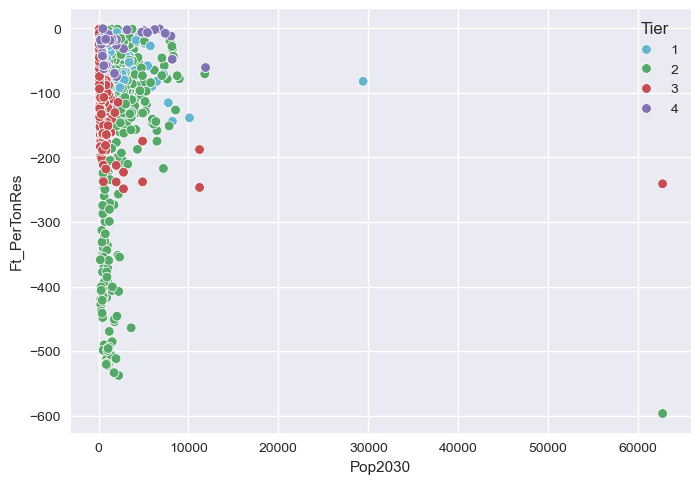

In [438]:
## Now we have tested this approach on one scenario, let us apply it to the remaining

## Looking closer at the Feedstock prices below zero
# Added a different hue based on MinimumOverall2030 technology

df_test = df[df.Ft_PerTonRes < 0]
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier', data=df_test, palette=palette)


<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

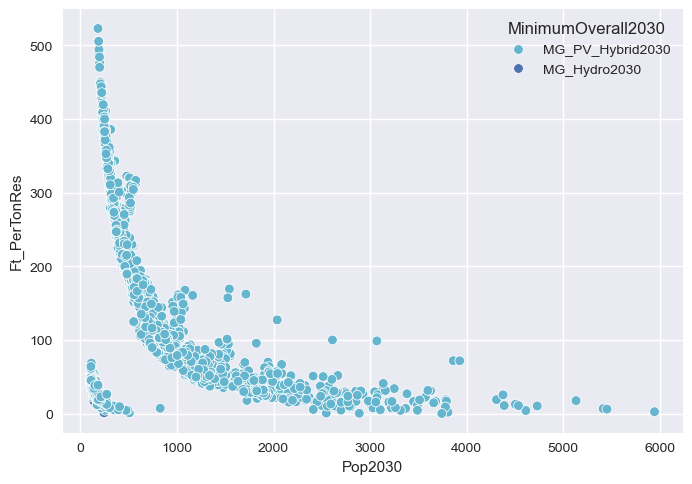

In [525]:
## Isolating individual Tiers and using limit on LCOE for different Tiers to understand population limit

df_test = df[df.Ft_PerTonRes > 0]
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'MinimumOverall2030', data=df_test[(df_test.Tier == 4)], palette=palette2)




In [470]:
#At Tier 3, less than 400 persons. Tier 4, less than 8,000 persons
# Tier 2, less than 10,000. Tier 1 is 12,000
#Tier 5 less 140 persons


ng-2-0_0_0_0_1_0-results
ng-2-0_0_0_1_1_0-results
ng-2-0_1_0_0_1_0-results
ng-2-0_1_0_1_1_0-results
ng-2-2_0_0_0_1_0-results
ng-2-2_0_0_1_1_0-results


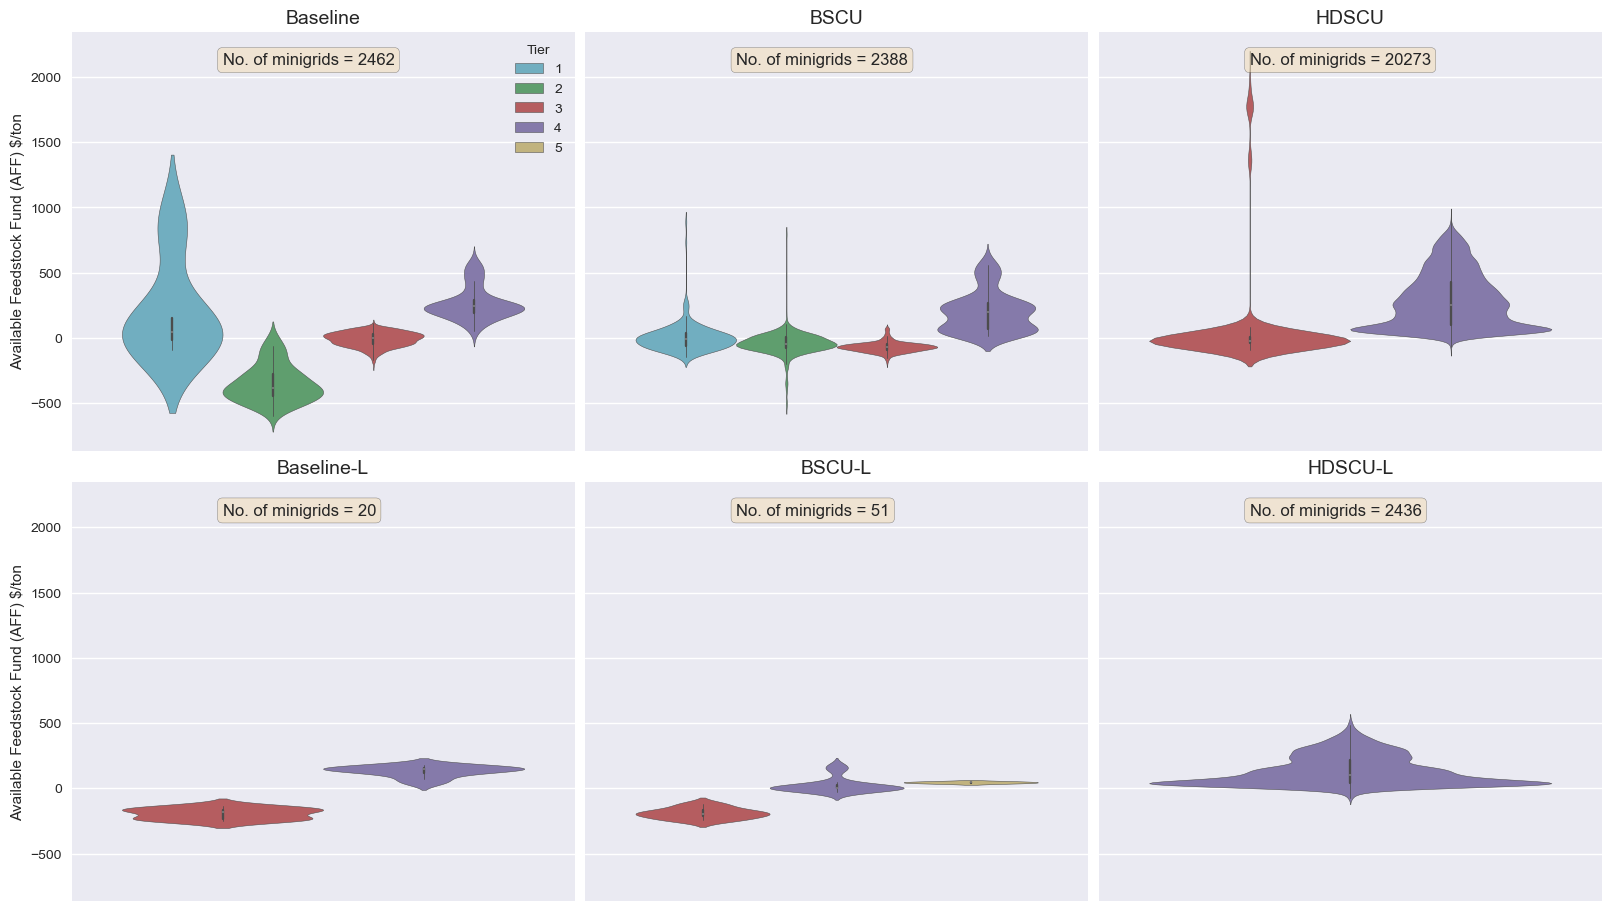

In [5]:
path=os.getcwd()+ '/results'

plt.style.use('seaborn-v0_8')
figure, axis = plt.subplots(2, 3, figsize=(16,9),layout='constrained', sharey=True)
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        textstr = f'No. of minigrids = {len(df)}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        print(scenario)     
        
        if scenario == 'ng-2-0_1_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,0],palette=palette, legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,0].text(0.3, 0.95, textstr, transform=axis[0,0].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[0,0].set_title('Baseline', fontsize=14)
            axis[0,0].set(xlabel=None)
            
            
        elif scenario == 'ng-2-0_1_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,0],palette=palette, legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,0].text(0.3, 0.95, textstr, transform=axis[1,0].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[1,0].set_title('Baseline-L', fontsize=14)
        
        elif scenario == 'ng-2-0_0_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,1],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,1].text(0.3, 0.95, textstr, transform=axis[0,1].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[0,1].set_title('BSCU', fontsize=14)
            axis[0,1].set(xlabel=None)
            
        elif scenario == 'ng-2-0_0_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,1],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,1].text(0.3, 0.95, textstr, transform=axis[1,1].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[1,1].set_title('BSCU-L', fontsize=14)
            
        elif scenario == 'ng-2-2_0_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,2],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,2].text(0.3, 0.95, textstr, transform=axis[0,2].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[0,2].set_title('HDSCU', fontsize=14)
            axis[0,2].set(xlabel=None)
            
        elif scenario == 'ng-2-2_0_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,2],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,2].text(0.3, 0.95, textstr, transform=axis[1,2].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[1,2].set_title('HDSCU-L', fontsize=14)
sns.despine()


handles1, labels1 = axis[0,1].get_legend_handles_labels()
handles2, labels2 = axis[1,1].get_legend_handles_labels()

handles = handles1 + [handles2[-1]]
labels1.append(labels2[-1])

axis[0,0].legend(handles, labels1, loc='upper right', title='Tier')

axis[1,1].get_legend().remove()
axis[0,1].get_legend().remove()


plt.setp(axis[:, 0], ylabel='Available Feedstock Fund (AFF) $/ton')
plt.show()




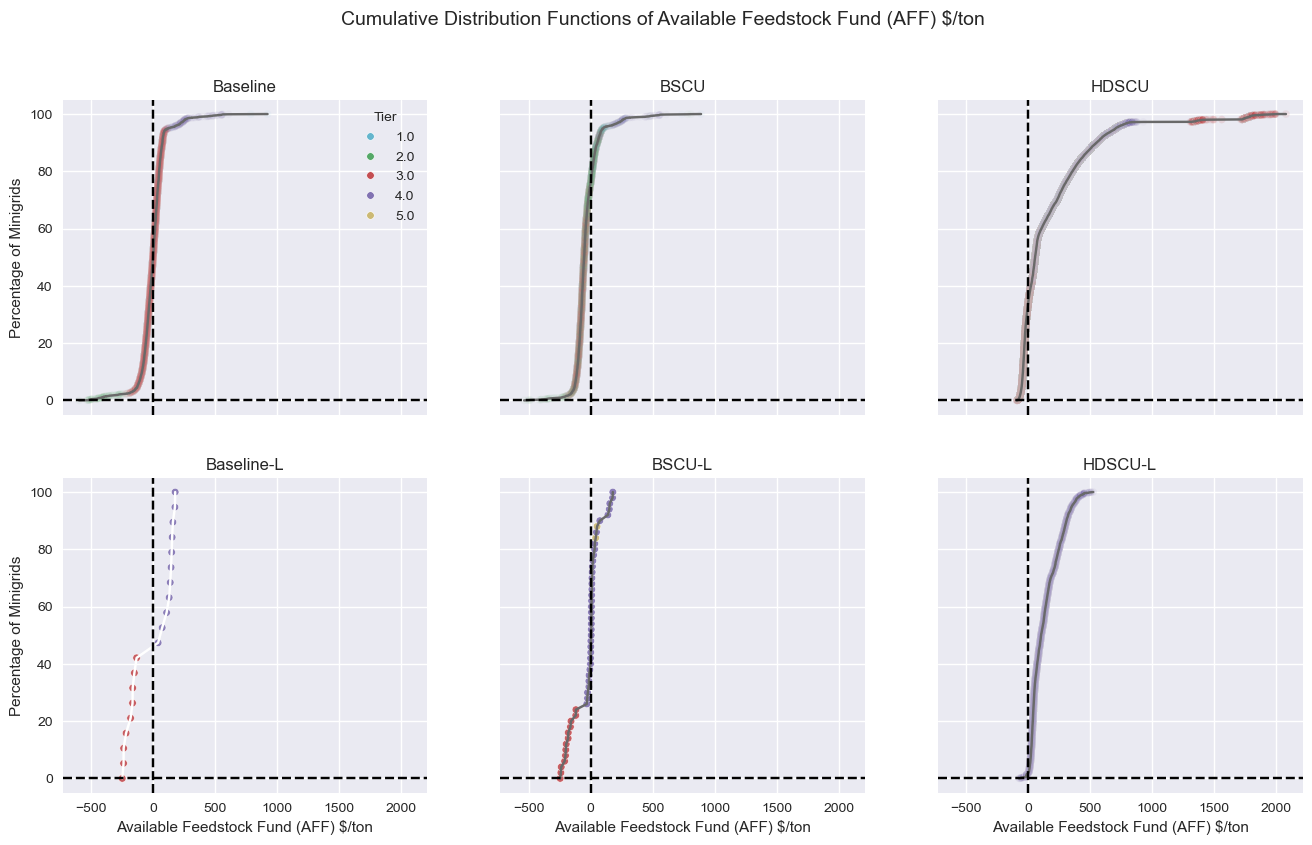

In [9]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('CDF.csv')
cdfCol = df.columns
figure, axis = plt.subplots(2, 3, figsize=(16,9),sharey=True, sharex=True)


textstr = f'No. of minigrids = 2388'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-2-0_0_0_0_1_0',y='ng-2-0_0_0_0_1_0-cum', ax= axis[0,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_0_0_0_1_0', y='ng-2-0_0_0_0_1_0-cum', s=30, alpha=0.04, hue='ng-2-0_0_0_0_1_0-tier', ax=axis[0,1], palette=palette)
axis[0,1].set(title='BSCU')
axis[0,1].axvline(0, c='black', ls='--') 
axis[0,1].axhline(0, c='black', ls='--')
axis[0,1].get_legend().set_visible(True)
axis[0,1].legend(title='Tiers')
axis[0,1].set(xlabel=None)
# axis[0,1].text(0.3, 0.5, textstr, transform=axis[0,1].transAxes, fontsize=10, verticalalignment='center', bbox=props)


textstr = f'No. of minigrids = 51'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-2-0_0_0_1_1_0',y='ng-2-0_0_0_1_1_0-cum', ax= axis[1,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_0_0_1_1_0', y='ng-2-0_0_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-2-0_0_0_1_1_0-tier', ax=axis[1,1],palette=palette)
axis[1,1].set(title='BSCU-L')
axis[1,1].axvline(0, c='black', ls='--') 
axis[1,1].axhline(0, c='black', ls='--') 
axis[1,1].get_legend().set_visible(True)
axis[1,1].legend(title='Tiers')
axis[1,1].set(xlabel=None)
# axis[1,1].text(0.3, 0.5, textstr, transform=axis[1,1].transAxes, fontsize=10, verticalalignment='center', bbox=props)

textstr = f'No. of minigrids = 2462'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-2-0_1_0_0_1_0',y='ng-2-0_1_0_0_1_0-cum', ax= axis[0,0], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-0_1_0_0_1_0', y='ng-2-0_1_0_0_1_0-cum', s=30, alpha=0.05, hue='ng-2-0_1_0_0_1_0-tier', ax=axis[0,0],palette=palette, legend=None)
axis[0,0].set(title='Baseline')
axis[0,0].axvline(0, c='black', ls='--') 
axis[0,0].axhline(0, c='black', ls='--')
# axis[0,0].get_legend().set_visible(True)
# axis[0,0].legend(title='Tiers')
axis[0,0].set(xlabel=None)
# axis[0,0].text(0.3, 0.5, textstr, transform=axis[0,0].transAxes, fontsize=10, verticalalignment='center', bbox=props)


textstr = f'No. of minigrids = 20'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-2-0_1_0_1_1_0', y='ng-2-0_1_0_1_1_0-cum', ax= axis[1,0], color='white')
sns.scatterplot(data=df, x='ng-2-0_1_0_1_1_0', y='ng-2-0_1_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-2-0_1_0_1_1_0-tier', ax=axis[1,0],palette=palette)
axis[1,0].set(title='Baseline-L')
axis[1,0].axvline(0, c='black', ls='--') 
axis[1,0].axhline(0, c='black', ls='--')
axis[1,0].get_legend().set_visible(True)
axis[1,0].legend(title='Tiers')
axis[1,0].set(xlabel=None)
# axis[1,0].text(0.3, 0.5, textstr, transform=axis[1,0].transAxes, fontsize=10, verticalalignment='center', bbox=props)

textstr = f'No. of minigrids = 20273'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-2-2_0_0_0_1_0',y='ng-2-2_0_0_0_1_0-cum', ax= axis[0,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-2_0_0_0_1_0', y='ng-2-2_0_0_0_1_0-cum', s=30, alpha=0.05, hue='ng-2-2_0_0_0_1_0-tier', ax=axis[0,2],palette=palette)
axis[0,2].set(title='HDSCU')
axis[0,2].axvline(0, c='black', ls='--') 
axis[0,2].axhline(0, c='black', ls='--')
axis[0,2].get_legend().set_visible(True)
axis[0,2].legend(title='Tiers')
axis[0,2].set(xlabel=None)
# axis[0,2].text(0.3, 0.5, textstr, transform=axis[0,2].transAxes, fontsize=10, verticalalignment='center', bbox=props)

textstr = f'No. of minigrids = 2436'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-2-2_0_0_1_1_0',y='ng-2-2_0_0_1_1_0-cum', ax= axis[1,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-2-2_0_0_1_1_0', y='ng-2-2_0_0_1_1_0-cum', s=30, alpha=0.09, hue='ng-2-2_0_0_1_1_0-tier', ax=axis[1,2],palette=palette)
axis[1,2].set(title='HDSCU-L')
axis[1,2].axvline(0, c='black', ls='--') 
axis[1,2].axhline(0, c='black', ls='--')
axis[1,2].get_legend().set_visible(True)
axis[1,2].legend(title='Tiers')
axis[1,2].set(xlabel=None)
# axis[1,2].text(0.3, 0.5, textstr, transform=axis[1,2].transAxes, fontsize=10, verticalalignment='center', bbox=props)

    
figure.suptitle('Cumulative Distribution Functions of Available Feedstock Fund (AFF) $/ton', fontsize=14)
#figure.supxlabel('Ft_PerTonRes', fontsize= 14)
#figure.supylabel('Percentage of Minigrids', fontsize=14)

handles1, labels1 = axis[0,1].get_legend_handles_labels()
handles2, labels2 = axis[1,1].get_legend_handles_labels()

handles = handles1 + [handles2[-1]]
labels1.append(labels2[-1])

leg = axis[0,0].legend(handles, labels1, loc='upper right', title='Tier',framealpha=0.9)

for handle in leg.legend_handles:
            handle.set_alpha(1.0)


axis[1,1].get_legend().remove()
axis[1,0].get_legend().remove()
axis[1,2].get_legend().remove()
axis[0,1].get_legend().remove()
axis[0,2].get_legend().remove()


sns.despine()
plt.setp(axis[-1, :], xlabel='Available Feedstock Fund (AFF) $/ton')
plt.setp(axis[:, 0], ylabel='Percentage of Minigrids')
plt.show()

## Understanding investment requirements


In [51]:
path=os.getcwd()+ '/results-rerun'
investments = []
scenarios = []
techLabel = ["MG", "Bio"]

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('-')[2]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        df['MG_Investment'] = df['InvestmentCost2025'] + df['InvestmentCost2030']
        
        df = df[df.Ft_PerTonRes_rr > 0].reset_index()
        
        total_MG_investment = df['MG_Investment'].sum()/1000000  #in Millions of dollars
        total_Bio_investment = df.investment.sum()/1000000
        
        scenarios.extend([scenario, scenario])
        investments.extend([total_MG_investment, total_Bio_investment])
        



In [52]:
df_invest = pd.DataFrame({
    "scenario":scenarios,
    "investments": investments,
    "tech": np.tile(techLabel, 6)# three scenarios
})

In [53]:
df_invest

,scenario,investments,tech
0,0_0_0_0_1_0,65.968794,MG
1,0_0_0_0_1_0,45.686037,Bio
2,0_0_0_1_1_0,2.973218,MG
3,0_0_0_1_1_0,2.268421,Bio
4,0_1_0_0_1_0,74.544489,MG
5,0_1_0_0_1_0,43.157291,Bio
6,0_1_0_1_1_0,0.572618,MG
7,0_1_0_1_1_0,0.247602,Bio
8,2_0_0_0_1_0,1353.612848,MG
9,2_0_0_0_1_0,2182.415803,Bio


[Text(0, 0.5, 'Investments in millions of dollars ($)')]

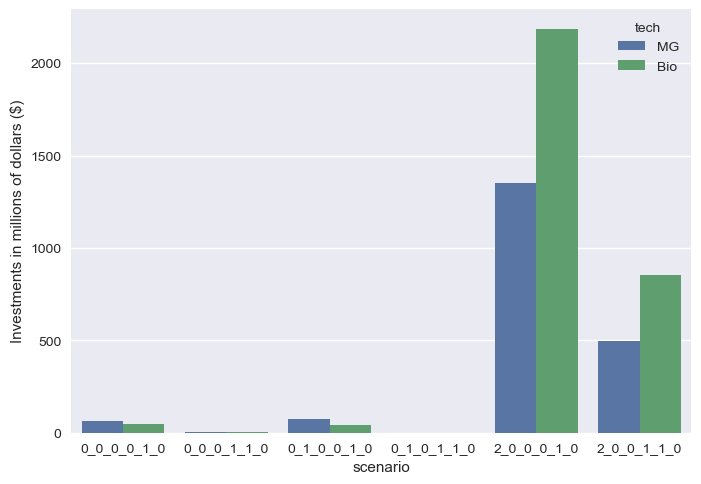

In [75]:
plt.style.use('seaborn')
ax = sns.barplot(x='scenario', y='investments', hue='tech', data=df_invest)
ax.set(ylabel='Investments in millions of dollars ($)')

In [69]:
df_invest_pivoted = df_invest.pivot(index=['tech'], columns='scenario', values='investments')
df_invest_pivoted['tech'] = ['Bio', 'MG']

In [68]:
df_invest_pivoted

scenario,0_0_0_0_1_0,0_0_0_1_1_0,0_1_0_0_1_0,0_1_0_1_1_0,2_0_0_0_1_0,2_0_0_1_1_0,tech
tech,,,,,,,
Bio,45.686037,2.268421,43.157291,0.247602,2182.415803,851.775046,MG
MG,65.968794,2.973218,74.544489,0.572618,1353.612848,495.759026,Bio


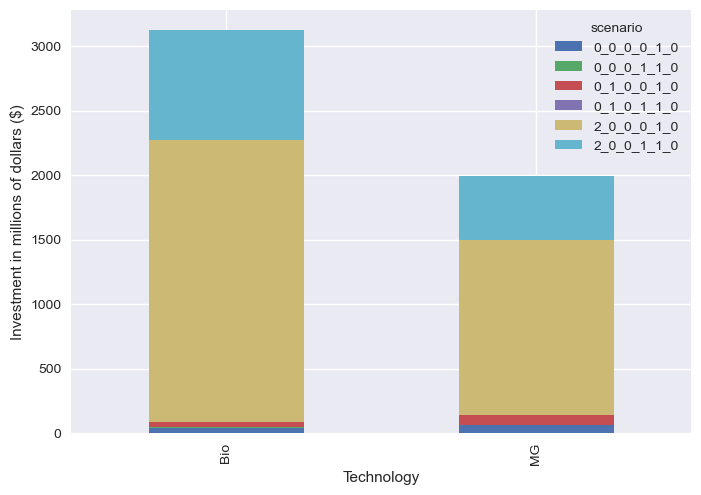

In [74]:
plt.style.use('seaborn')
df_invest_pivoted.plot(x='tech', kind='bar', stacked=True)
plt.xlabel("Technology")
plt.ylabel("Investment in millions of dollars ($)")
plt.show()

In [ ]:
# plot bars in stack manner
plt.bar(x, y1, color='r')
plt.bar(x, y2, bottom=y1, hue='scenario')
plt.show()

In [ ]:
df = pd.read_csv(path + '/ng-2-0_0_0_0_1_0-results-rr.csv')
df['MG_Investment'] = df['InvestmentCost2025'] + df['InvestmentCost2030']


df = df[df.Ft_PerTonRes_rr > 0].reset_index()

In [14]:
df.tail(5)



,index,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,InvestmentCost2025,...,CapFactor,GasifierCap,investment,NpvIt,NpvGen,NpvOM,NpvRes,NpvFt,Ft_PerTonRes_rr,MG_Investment
569,2380,0.404,2.771,8.870,533697,Kwara,1797.0,30142.125,2,101376.11,...,0.166667,68.817637,147957.919521,138278.429458,3.512638e+05,86211.996101,257.022264,5168.839962,20.110476,233267.510
570,2382,0.280,5.070,5.780,513656,Delta,7724.0,100530.625,1,370105.10,...,0.166667,229.521975,493472.246005,461189.014958,1.171542e+06,287535.993249,857.225854,205441.035088,239.658002,394783.428
571,2384,0.025,6.715,4.370,674267,Rivers,2494.0,33875.060,1,105964.96,...,0.166667,77.340320,166281.687215,155403.445995,3.947658e+05,96888.873649,288.853046,256971.020795,889.625450,119955.287
572,2385,0.070,5.484,4.875,509194,Bayelsa,972.0,12467.945,1,54332.51,...,0.166667,28.465628,61201.099886,57197.289613,1.452962e+05,35660.605406,140.609259,5401.521121,38.415117,114284.090
573,2386,0.131,5.410,5.060,679935,Bayelsa,4188.0,53708.070,1,199211.39,...,0.166667,122.621164,263635.503425,246388.320958,6.258915e+05,153614.913395,605.701414,444705.749265,734.199622,222727.228


In [15]:

total_MG_investment = df['MG_Investment'].sum()
total_Bio_investment = df.investment.sum()

print(f" Mini-grid investment: {total_MG_investment}, Bio-electrification equivalent {total_Bio_investment}")

 Mini-grid investment: 65968793.84900001, Bio-electrification equivalent 45686037.10171233


<AxesSubplot:xlabel='MinimumOverallLCOE2030', ylabel='MG_Investment'>

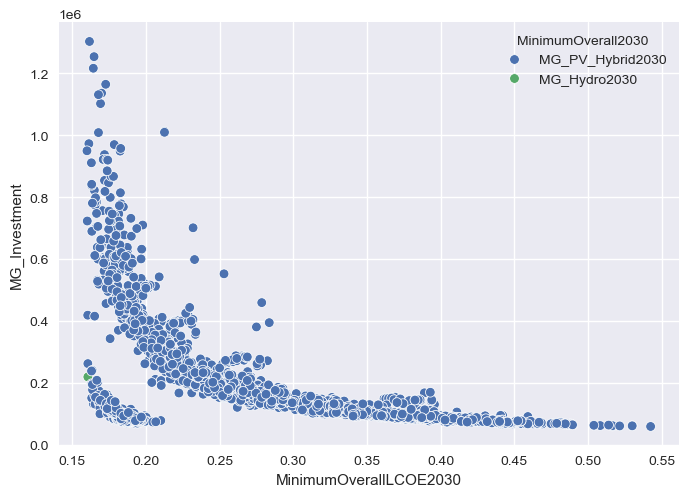

In [76]:
sns.scatterplot(x='MinimumOverallLCOE2030',y='MG_Investment', hue='MinimumOverall2030', data=df)
# Seems some clusters have low investment cost but still High LCOE. 
# As a result, some clusters have higher bio-electrification investment compared to the alternative

In [77]:
df

,index,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,InvestmentCost2025,...,CapFactor,GasifierCap,investment,NpvIt,NpvGen,NpvOM,NpvRes,NpvFt,Ft_PerTonRes_rr,MG_Investment
0,0,0.009,8.220,5.766,685551,Cross River,108.9,40568.370,4,40089.285,...,0.666667,23.155462,49784.244007,46527.330848,4.727669e+05,29008.241425,345.926981,14724.119042,42.564240,74191.601
1,1,0.140,8.840,5.633,673339,Cross River,1204.0,448691.060,4,296464.970,...,0.666667,256.102203,550619.736872,514597.884927,5.228859e+06,320834.645161,3825.994090,277104.154569,72.426707,314094.568
2,2,0.027,8.200,5.637,673350,Cross River,136.9,53730.867,4,52089.773,...,0.666667,30.668303,65936.851627,61623.225819,6.261571e+05,38420.029247,458.163752,14915.280120,32.554474,93901.383
3,3,0.079,8.695,5.660,672883,Cross River,547.5,174216.550,4,138226.470,...,0.666667,99.438670,213793.140696,199806.673548,2.030247e+06,124572.807402,1485.546627,337830.008166,227.411245,152327.960
4,4,0.069,13.700,12.180,151054,Borno,668.5,249075.830,4,165244.250,...,0.666667,142.166570,305658.124715,285661.798799,2.902626e+06,178100.619024,2136.902505,282444.875985,132.174901,180435.590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2383,2431,0.030,5.395,5.490,514603,Delta,182.9,57700.090,4,55740.945,...,0.666667,32.933841,70807.758847,66175.475558,6.724128e+05,41258.205369,492.009365,19054.126939,38.727163,103556.495
2384,2432,0.010,5.395,5.496,684049,Delta,109.7,34620.055,4,39389.523,...,0.666667,19.760305,42484.656535,39705.286482,4.034477e+05,24754.923937,295.205627,18130.338544,61.415965,72972.503
2385,2433,0.015,5.402,5.535,671530,Delta,109.7,34620.055,4,39487.800,...,0.666667,19.760305,42484.656535,39705.286482,4.034477e+05,24754.923937,295.205627,18918.322315,64.085236,73633.030
2386,2434,0.053,5.410,5.465,684643,Delta,585.0,184640.280,4,142287.530,...,0.666667,105.388288,226584.818493,211761.512610,2.151721e+06,132026.251462,1574.429898,327049.037574,207.725373,156721.277
